## modeling on STN_0001

### train set <2025-08-01,  test set >2025-08-01

### output:
- columns to output for modelling: 
        - canonical_station_id, ts_hour, station_netflow, model_netflow

#### feature selection as resuable helper function: 
- run_exploratory_univariate_screen(...)
- split_time_series_train_val_test(...)
- prepare_datasets_with_feature_selection(...)

#### `selected features now actually drive downstream training:`

VectorSlicer is applied inside the reusable prep function, tree models use the reduced raw vector, and linear / GLR models use the reduced scaled vector

In [38]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import udf
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.regression import GeneralizedLinearRegression
from pyspark.ml.feature import VectorAssembler

import matplotlib.pyplot as plt
import pandas as pd
import json
import math
import os
import re

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, UnivariateFeatureSelector, VectorSlicer
from pyspark.ml import Pipeline
import seaborn as sns

In [39]:
# read 2 functions from bixi-analytics/utils/yc__loss_func.py
import sys
sys.path.append('../utils')  # go up one level
from yc__loss_func import asymmetric_loss_col, asymmetric_loss_mean


In [40]:
# Stop any existing SparkSession to avoid conflicts
if 'spark' in locals() and spark is not None:
    spark.stop()

spark = SparkSession.builder.appName("stn0001-modeling").getOrCreate()
print(spark.version)
spark

4.1.1


Get Data from GOLD

In [41]:
gold_parquet_path = '../../data/gold/station_flow/station_id=STN_0001/'

# Load the parquet files into a Spark DataFrame
gold_0001_df = spark.read.parquet(gold_parquet_path)

# --- IGNORE --- not required –––––––––
# # Filter rides to include only months between April (4) and October (10) for both start and end times
# ride_df = ride_df.filter(
#     (F.month("start_time_ms") >= 4) & (F.month("start_time_ms") <= 10) &
#     (F.month("end_time_ms") >= 4) & (F.month("end_time_ms") <= 10)
# )

print(f"Loaded and filtered gold_0001_df with {gold_0001_df.count()} rows and {len(gold_0001_df.columns)} columns.")
gold_0001_df.printSchema()
gold_0001_df.show(5)

Loaded and filtered gold_0001_df with 24614 rows and 64 columns.
root
 |-- ts_hour: timestamp (nullable = true)
 |-- station_inflow: long (nullable = true)
 |-- station_outflow: long (nullable = true)
 |-- station_netflow: long (nullable = true)
 |-- radius100m_inflow_lag1: long (nullable = true)
 |-- radius100m_outflow_lag1: long (nullable = true)
 |-- radius100m_inflow_lag12: long (nullable = true)
 |-- radius100m_outflow_lag12: long (nullable = true)
 |-- radius100m_inflow_rollmean6: double (nullable = true)
 |-- radius100m_outflow_rollmean6: double (nullable = true)
 |-- radius100m_inflow_rollmean12: double (nullable = true)
 |-- radius100m_outflow_rollmean12: double (nullable = true)
 |-- radius100m_inflow_rollsum6: long (nullable = true)
 |-- radius100m_outflow_rollsum6: long (nullable = true)
 |-- radius100m_inflow_rollsum12: long (nullable = true)
 |-- radius100m_outflow_rollsum12: long (nullable = true)
 |-- radius200m_inflow_lag1: long (nullable = true)
 |-- radius200m_outflo

## Prediction Target: Inflow
## Output Model: Inflow model

## Inflow modeling: exploratory diagnostics

In [42]:
ALL_COLUMNS = ['ts_hour', 'station_inflow', 'station_outflow', 'station_netflow', 'radius100m_inflow_lag1', 'radius100m_outflow_lag1', 'radius100m_inflow_lag12', 'radius100m_outflow_lag12', 'radius100m_inflow_rollmean6', 'radius100m_outflow_rollmean6', 'radius100m_inflow_rollmean12', 'radius100m_outflow_rollmean12', 'radius100m_inflow_rollsum6', 'radius100m_outflow_rollsum6', 'radius100m_inflow_rollsum12', 'radius100m_outflow_rollsum12', 'radius200m_inflow_lag1', 'radius200m_outflow_lag1', 'radius200m_inflow_lag12', 'radius200m_outflow_lag12', 'radius200m_inflow_rollmean6', 'radius200m_outflow_rollmean6', 'radius200m_inflow_rollmean12', 'radius200m_outflow_rollmean12', 'radius200m_inflow_rollsum6', 'radius200m_outflow_rollsum6', 'radius200m_inflow_rollsum12', 'radius200m_outflow_rollsum12', 'radius500m_inflow_lag1', 'radius500m_outflow_lag1', 'radius500m_inflow_lag12', 'radius500m_outflow_lag12', 'radius500m_inflow_rollmean6', 'radius500m_outflow_rollmean6', 'radius500m_inflow_rollmean12', 'radius500m_outflow_rollmean12', 'radius500m_inflow_rollsum6', 'radius500m_outflow_rollsum6', 'radius500m_inflow_rollsum12', 'radius500m_outflow_rollsum12', 'temp', 'precip', 'station_inflow_lag1', 'station_outflow_lag1', 'station_inflow_lag12', 'station_outflow_lag12', 'precip_rollmean3', 'station_inflow_rollmean6', 'station_outflow_rollmean6', 'station_inflow_rollmean12', 'station_outflow_rollmean12', 'precip_rollsum3', 'station_inflow_rollsum6', 'station_outflow_rollsum6', 'station_inflow_rollsum12', 'station_outflow_rollsum12', 'temp_bin', 'dow', 'is_weekday', 'hod', 'moy', 'dow_cos', 'hod_cos', 'moy_cos']

TIME_COL = "ts_hour"
TARGET_COL = "station_inflow"   # change to station_outflow or station_netflow as needed

# features to exclude from predictors
BASE_EXCLUDE = [TIME_COL, "station_inflow", "station_outflow", "station_netflow"]

# categorical columns detected from your schema preview
CATEGORICAL_COLS = ["temp_bin"]

# boolean columns
BOOLEAN_COLS = ["is_weekday"]

# numeric columns inferred from your schema preview
NUMERIC_COLS = [c for c in ALL_COLUMNS if c not in BASE_EXCLUDE + CATEGORICAL_COLS + BOOLEAN_COLS]

print("Target:", TARGET_COL)
print("Numeric feature count:", len(NUMERIC_COLS))
print("Categorical feature count:", len(CATEGORICAL_COLS))
print("Boolean feature count:", len(BOOLEAN_COLS))

Target: station_inflow
Numeric feature count: 58
Categorical feature count: 1
Boolean feature count: 1


In [43]:
# reusable helpers for feature preparation and selection

def get_feature_names_from_pipeline_model(pipeline_model, numeric_cols, boolean_cols, categorical_cols):
    feature_names = list(numeric_cols) + list(boolean_cols)
    for c in categorical_cols:
        idx_model = next(
            s for s in pipeline_model.stages
            if hasattr(s, "getOutputCol") and s.getOutputCol() == f"{c}_idx"
        )
        labels = list(idx_model.labels) + ["__unknown__"]
        usable = labels[:-1] if len(labels) > 1 else labels
        feature_names.extend([f"{c}={lab}" for lab in usable])
    return feature_names


def run_exploratory_univariate_screen(
    source_df,
    target_col,
    time_col,
    numeric_cols,
    boolean_cols,
    categorical_cols,
    top_k=25
):
    fill_map = {c: 0.0 for c in numeric_cols}
    fill_map.update({c: 0 for c in boolean_cols})
    screen_df = source_df.fillna(fill_map)

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in categorical_cols
    ]
    encoders = [
        OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"])
        for c in categorical_cols
    ]

    feature_inputs = numeric_cols + boolean_cols + [f"{c}_ohe" for c in categorical_cols]
    assembler = VectorAssembler(inputCols=feature_inputs, outputCol="features_raw", handleInvalid="keep")
    scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

    screen_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
    screen_model = screen_pipe.fit(screen_df)
    screen_ready = screen_model.transform(screen_df).select(time_col, target_col, "features_raw", "features_scaled")

    screen_feature_names = get_feature_names_from_pipeline_model(
        screen_model, numeric_cols, boolean_cols, categorical_cols
    )

    """explanation of setting selectionThreshold :::: ====== ::::
    Your environment is using a PySpark wrapper where __init__() only exposes a smaller set of keyword arguments, 
    so selectionThreshold is rejected at construction time. But the parameter still exists on the estimator object itself, 
    which is why the setter approach works. This mismatch is consistent with the Spark docs, 
    where selectionThreshold is documented as a param and setter rather than something guaranteed to be accepted in every constructor signature.
    """
    screen_top_k = min(top_k, len(screen_feature_names))
    # screen_selector = UnivariateFeatureSelector(
    #     featuresCol="features_scaled",
    #     outputCol="features_screened",
    #     labelCol=target_col,
    #     selectionMode="numTopFeatures",
    #     selectionThreshold=screen_top_k,
    #     featureType="continuous",
    #     labelType="continuous"
    # )
    screen_selector = (
        UnivariateFeatureSelector(
            featuresCol="features_scaled",
            outputCol="features_screened",
            labelCol=target_col
        )
        .setFeatureType("continuous")
        .setLabelType("continuous")
        .setSelectionMode("numTopFeatures")
        .setSelectionThreshold(screen_top_k)
    )
    screen_selector_model = screen_selector.fit(screen_ready)
    selected_indices = [int(i) for i in list(screen_selector_model.selectedFeatures)]
    selected_features = [screen_feature_names[i] for i in selected_indices]

    selection_pdf = pd.DataFrame({
        "rank": range(1, len(selected_indices) + 1),
        "feature_index": selected_indices,
        "feature": selected_features
    })

    return {
        "screen_model": screen_model,
        "screen_ready": screen_ready,
        "screen_feature_names": screen_feature_names,
        "selected_feature_indices": selected_indices,
        "selected_features": selected_features,
        "selection_pdf": selection_pdf,
        "screen_top_k": screen_top_k,
    }


def split_time_series_train_val_test(source_df, time_col, train_frac=0.8, val_frac_within_train=0.8):
    time_bounds = source_df.select(
        F.min(time_col).alias("min_ts"),
        F.max(time_col).alias("max_ts")
    ).first()

    timeline = source_df.select(time_col).distinct().orderBy(time_col)
    n_time_points = timeline.count()
    split_idx = int(math.floor(n_time_points * train_frac))
    split_ts = timeline.collect()[split_idx - 1][time_col] if split_idx > 0 else time_bounds["min_ts"]

    train_full_df = source_df.filter(F.col(time_col) <= F.lit(split_ts))
    test_df = source_df.filter(F.col(time_col) > F.lit(split_ts))

    train_timeline = train_full_df.select(time_col).distinct().orderBy(time_col)
    n_train_time_points = train_timeline.count()
    val_start_idx = int(math.floor(n_train_time_points * val_frac_within_train))
    val_start_ts = train_timeline.collect()[val_start_idx - 1][time_col] if val_start_idx > 0 else split_ts

    train_df = train_full_df.filter(F.col(time_col) <= F.lit(val_start_ts))
    val_df = train_full_df.filter(F.col(time_col) > F.lit(val_start_ts))

    return {
        "min_ts": time_bounds["min_ts"],
        "max_ts": time_bounds["max_ts"],
        "n_time_points": n_time_points,
        "split_ts": split_ts,
        "val_start_ts": val_start_ts,
        "train_full_df": train_full_df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
    }

def prepare_datasets_with_feature_selection(
    train_df,
    val_df,
    test_df,
    target_col,
    numeric_cols,
    boolean_cols,
    categorical_cols,
    use_screened_features=True,
    selector_top_k=25
):
    fill_map = {c: 0.0 for c in numeric_cols}
    fill_map.update({c: 0 for c in boolean_cols})

    train_filled = train_df.fillna(fill_map)
    val_filled = val_df.fillna(fill_map)
    test_filled = test_df.fillna(fill_map)

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in categorical_cols
    ]
    encoders = [
        OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"])
        for c in categorical_cols
    ]

    feature_inputs = numeric_cols + boolean_cols + [f"{c}_ohe" for c in categorical_cols]
    assembler = VectorAssembler(
        inputCols=feature_inputs,
        outputCol="features_raw",
        handleInvalid="keep"
    )
    scaler = StandardScaler(
        inputCol="features_raw",
        outputCol="features_scaled",
        withMean=False,
        withStd=True
    )

    prep_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
    prep_model = prep_pipe.fit(train_filled)

    full_model_feature_names = get_feature_names_from_pipeline_model(
        prep_model, numeric_cols, boolean_cols, categorical_cols
    )

    tree_features_col = "features_raw"
    linear_features_col = "features_scaled"
    selected_feature_indices = list(range(len(full_model_feature_names)))
    model_feature_names = list(full_model_feature_names)
    selector_model = None
    raw_slicer = None
    scaled_slicer = None

    if use_screened_features:
        selector_top_k = min(selector_top_k, len(full_model_feature_names))
        # selector = UnivariateFeatureSelector(
        #     featuresCol="features_scaled",
        #     outputCol="features_selected_scaled",
        #     labelCol=target_col,
        #     selectionMode="numTopFeatures",
        #     selectionThreshold=selector_top_k,
        #     featureType="continuous",
        #     labelType="continuous"
        # )
        
        selector = (
            UnivariateFeatureSelector(
                featuresCol="features_scaled",
                outputCol="features_selected_scaled",
                labelCol=target_col
            )
            .setFeatureType("continuous")
            .setLabelType("continuous")
            .setSelectionMode("numTopFeatures")
            .setSelectionThreshold(selector_top_k)
        )

        train_ready_for_fit = prep_model.transform(train_filled)
        selector_model = selector.fit(train_ready_for_fit)

        selected_feature_indices = [
            int(i) for i in list(selector_model.selectedFeatures)
        ]
        model_feature_names = [
            full_model_feature_names[i] for i in selected_feature_indices
        ]

        raw_slicer = VectorSlicer(
            inputCol="features_raw",
            outputCol="features_selected_raw",
            indices=selected_feature_indices
        )
        scaled_slicer = VectorSlicer(
            inputCol="features_scaled",
            outputCol="features_selected_scaled",
            indices=selected_feature_indices
        )

        tree_features_col = "features_selected_raw"
        linear_features_col = "features_selected_scaled"

    def apply_full_prep(df):
        out = prep_model.transform(df.fillna(fill_map))
        if use_screened_features:
            out = raw_slicer.transform(out)
            out = scaled_slicer.transform(out)
        return out

    train_ready = apply_full_prep(train_df)
    val_ready = apply_full_prep(val_df)
    test_ready = apply_full_prep(test_df)

    selection_pdf = pd.DataFrame({
        "rank": range(1, len(selected_feature_indices) + 1),
        "feature_index": selected_feature_indices,
        "feature": model_feature_names
    })

    return {
        "fill_map": fill_map,
        "prep_model": prep_model,
        "selector_model": selector_model,
        "raw_slicer": raw_slicer,
        "scaled_slicer": scaled_slicer,
        "apply_full_prep": apply_full_prep,
        "train_ready": train_ready,
        "val_ready": val_ready,
        "test_ready": test_ready,
        "tree_features_col": tree_features_col,
        "linear_features_col": linear_features_col,
        "model_feature_names": model_feature_names,
        "full_model_feature_names": full_model_feature_names,
        "selected_feature_indices": selected_feature_indices,
        "selection_pdf": selection_pdf,
        "train_df": train_filled,
        "val_df": val_filled,
        "test_df": test_filled,
    }
   


In [44]:
# for col in NUMERIC_COLS[:5]:
#     plt.figure(figsize=(3, 2))  
#     plt.scatter(pdf[col], pdf[TARGET_COL], alpha=0.3)
#     plt.title(f"{col} vs Target")
#     plt.show()

In [45]:
# Define the evaluators for each metric
evaluator_rmse = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="r2")

print("Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2")

Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2


In [46]:
# preview = gold_0001_df.limit(1).toPandas()
# preview.to_csv("schema_preview.csv", index=False)

In [47]:
# Time-based Split

# define cutoff date
cutoff_date = "2025-08-01"
# split data
train_df = gold_0001_df.filter(F.col("ts_hour") < cutoff_date)
test_df  = gold_0001_df.filter(F.col("ts_hour") >= cutoff_date)

# sanity checks
print(f"Cutoff date: {cutoff_date}")
print(f"Data ready. Total rows: {gold_0001_df.count()}")
print(f"Training set: {train_df.count()} rows")
print(f"Testing set: {test_df.count()} rows")


Cutoff date: 2025-08-01
Data ready. Total rows: 24614
Training set: 20185 rows
Testing set: 4429 rows


In [48]:
SCREEN_TOP_K = 25

inflow_screen_ctx = run_exploratory_univariate_screen(
    source_df=gold_0001_df,
    target_col=TARGET_COL,
    time_col=TIME_COL,
    numeric_cols=NUMERIC_COLS,
    boolean_cols=BOOLEAN_COLS,
    categorical_cols=CATEGORICAL_COLS,
    top_k=SCREEN_TOP_K
)

screen_ready = inflow_screen_ctx["screen_ready"]
screen_feature_names = inflow_screen_ctx["screen_feature_names"]
screen_selected_feature_indices = inflow_screen_ctx["selected_feature_indices"]
screen_selected_features = inflow_screen_ctx["selected_features"]
ufs_screen_pdf = inflow_screen_ctx["selection_pdf"]

print("Exploratory screening rows:", screen_ready.count())
print("UnivariateFeatureSelector shortlisted features:", len(screen_selected_features))
ufs_screen_pdf.head(20)

Exploratory screening rows: 24614
UnivariateFeatureSelector shortlisted features: 25


,rank,feature_index,feature
0,1,0,radius100m_inflow_lag1
1,2,1,radius100m_outflow_lag1
2,3,2,radius100m_inflow_lag12
3,4,4,radius100m_inflow_rollmean6
4,5,5,radius100m_outflow_rollmean6
5,6,6,radius100m_inflow_rollmean12
6,7,7,radius100m_outflow_rollmean12
7,8,8,radius100m_inflow_rollsum6
8,9,9,radius100m_outflow_rollsum6
9,10,10,radius100m_inflow_rollsum12


In [49]:
# full shortlist from exploratory UnivariateFeatureSelector
ufs_screen_pdf

,rank,feature_index,feature
0,1,0,radius100m_inflow_lag1
1,2,1,radius100m_outflow_lag1
2,3,2,radius100m_inflow_lag12
3,4,4,radius100m_inflow_rollmean6
4,5,5,radius100m_outflow_rollmean6
5,6,6,radius100m_inflow_rollmean12
6,7,7,radius100m_outflow_rollmean12
7,8,8,radius100m_inflow_rollsum6
8,9,9,radius100m_outflow_rollsum6
9,10,10,radius100m_inflow_rollsum12


In [50]:
# keep the exploratory shortlist visible for reference
screen_top_union = list(screen_selected_features)
print('Shortlisted features:', len(screen_top_union))
screen_top_union[:20]

Shortlisted features: 25


['radius100m_inflow_lag1',
 'radius100m_outflow_lag1',
 'radius100m_inflow_lag12',
 'radius100m_inflow_rollmean6',
 'radius100m_outflow_rollmean6',
 'radius100m_inflow_rollmean12',
 'radius100m_outflow_rollmean12',
 'radius100m_inflow_rollsum6',
 'radius100m_outflow_rollsum6',
 'radius100m_inflow_rollsum12',
 'radius100m_outflow_rollsum12',
 'radius200m_inflow_lag1',
 'radius200m_outflow_lag1',
 'radius200m_inflow_lag12',
 'radius200m_inflow_rollmean6',
 'radius200m_outflow_rollmean6',
 'radius200m_inflow_rollmean12',
 'radius200m_outflow_rollmean12',
 'radius200m_inflow_rollsum6',
 'radius200m_outflow_rollsum6']

In [51]:
inflow_split_ctx = split_time_series_train_val_test(
    source_df=gold_0001_df,
    time_col=TIME_COL,
    train_frac=0.8,
    val_frac_within_train=0.8
)

min_ts = inflow_split_ctx["min_ts"]
max_ts = inflow_split_ctx["max_ts"]
n_time_points = inflow_split_ctx["n_time_points"]
split_ts = inflow_split_ctx["split_ts"]

train_full_df = inflow_split_ctx["train_full_df"]
train_df = inflow_split_ctx["train_df"]
val_df = inflow_split_ctx["val_df"]
test_df = inflow_split_ctx["test_df"]

print("Min timestamp:", min_ts)
print("Max timestamp:", max_ts)
print("Distinct time points:", n_time_points)
print("80/20 split timestamp:", split_ts)
print("Train_full rows:", train_full_df.count())
print("Test rows:", test_df.count())

Min timestamp: 2023-04-12 23:00:00
Max timestamp: 2026-02-01 12:00:00
Distinct time points: 24614
80/20 split timestamp: 2025-07-11 09:00:00
Train_full rows: 19691
Test rows: 4923


## Inflow modeling: final pipeline path

This section uses the reusable feature-preparation helpers so the selected features are the same ones used by downstream training.

In [52]:
print("Train rows:", train_df.count())
print("Validation rows:", val_df.count())
print("Validation start timestamp:", inflow_split_ctx["val_start_ts"])

Train rows: 15752
Validation rows: 3939
Validation start timestamp: 2025-01-28 06:00:00


Apply the reusable preparation function below. This is the pipeline path that feeds the baseline, tuning, and final-training cells.

In [53]:
USE_SCREENED_FEATURES = True

inflow_prep_ctx = prepare_datasets_with_feature_selection(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=TARGET_COL,
    numeric_cols=NUMERIC_COLS,
    boolean_cols=BOOLEAN_COLS,
    categorical_cols=CATEGORICAL_COLS,
    use_screened_features=USE_SCREENED_FEATURES,
    selector_top_k=SCREEN_TOP_K
)

fill_map = inflow_prep_ctx["fill_map"]
prep_model = inflow_prep_ctx["prep_model"]
train_ready = inflow_prep_ctx["train_ready"]
val_ready = inflow_prep_ctx["val_ready"]
test_ready = inflow_prep_ctx["test_ready"]
TREE_FEATURES_COL = inflow_prep_ctx["tree_features_col"]
LINEAR_FEATURES_COL = inflow_prep_ctx["linear_features_col"]
model_feature_names = inflow_prep_ctx["model_feature_names"]
full_model_feature_names = inflow_prep_ctx["full_model_feature_names"]
selected_feature_indices = inflow_prep_ctx["selected_feature_indices"]
ufs_train_pdf = inflow_prep_ctx["selection_pdf"]

print("Using screened features:", USE_SCREENED_FEATURES)
print("Prepared feature count used downstream:", len(model_feature_names))
display(ufs_train_pdf.head(20))

Using screened features: True
Prepared feature count used downstream: 25


,rank,feature_index,feature
0,1,0,radius100m_inflow_lag1
1,2,1,radius100m_outflow_lag1
2,3,2,radius100m_inflow_lag12
3,4,3,radius100m_outflow_lag12
4,5,4,radius100m_inflow_rollmean6
5,6,5,radius100m_outflow_rollmean6
6,7,6,radius100m_inflow_rollmean12
7,8,7,radius100m_outflow_rollmean12
8,9,8,radius100m_inflow_rollsum6
9,10,9,radius100m_outflow_rollsum6


In [54]:
evaluator_specs = ["rmse", "mae", "r2"]

def evaluate_predictions(pred_df, label_col=TARGET_COL):
    out = {}
    for metric in evaluator_specs:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
        out[metric] = ev.evaluate(pred_df)
    return out

def fit_and_evaluate(model_name, estimator, train_data, eval_data, features_col):
    fitted = estimator.fit(train_data)
    pred = fitted.transform(eval_data)
    metrics = evaluate_predictions(pred, TARGET_COL)
    return {
        "model_name": model_name,
        "features_col": features_col,
        "fitted_model": fitted,
        "predictions": pred,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }

def extract_tree_importance(model, feature_names):
    if hasattr(model, "featureImportances"):
        return pd.DataFrame({
            "feature": feature_names,
            "importance": list(model.featureImportances.toArray())
        }).sort_values("importance", ascending=False)
    return None

def extract_linear_importance(model, feature_names):
    if hasattr(model, "coefficients"):
        pdf = pd.DataFrame({
            "feature": feature_names,
            "coefficient": list(model.coefficients.toArray())
        })
        pdf["abs_coefficient"] = pdf["coefficient"].abs()
        return pdf.sort_values("abs_coefficient", ascending=False)
    return None

#### 11. First-round baseline training

Design choice:
- tree models use `features_raw`
- linear models use `features_scaled`
- Poisson GLR assumes a non-negative target, so use it mainly for `station_inflow` or `station_outflow`

Model Training - To Try All types of Time Series Regression supported by Spark

In [55]:
baseline_models = {
    "GBTRegressor": GBTRegressor(
        featuresCol=TREE_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        maxDepth=5,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=1.0,
        seed=42
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol=TREE_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        numTrees=100,
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol=TREE_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "LinearRegression": LinearRegression(
        featuresCol=LINEAR_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.1,
        elasticNetParam=0.0
    ),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(
        featuresCol=LINEAR_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        family="poisson",
        link="log",
        maxIter=50,
        regParam=0.0
    )
}


In [56]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        print(f"Skipping {model_name} because Poisson GLR is not suitable for negative netflow targets.")
        continue

    features_col = estimator.getFeaturesCol()
    result = fit_and_evaluate(model_name, estimator, train_ready, val_ready, features_col)
    baseline_results.append(result)
    print(model_name, {k: result[k] for k in ['rmse', 'mae', 'r2']})

baseline_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in baseline_results
]).sort_values("rmse")

baseline_metrics_pdf

GBTRegressor {'rmse': 5.230588139761211, 'mae': 3.1378282068409056, 'r2': 0.8543265374386787}


26/04/18 11:22:47 WARN DAGScheduler: Broadcasting large task binary with size 1255.6 KiB
26/04/18 11:22:49 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/04/18 11:22:52 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
26/04/18 11:22:54 WARN DAGScheduler: Broadcasting large task binary with size 1136.2 KiB


RandomForestRegressor {'rmse': 5.254527100370355, 'mae': 3.1297986342926447, 'r2': 0.8529900715084527}


DecisionTreeRegressor {'rmse': 5.682928088062471, 'mae': 3.3633366611776294, 'r2': 0.8280414735823733}


LinearRegression {'rmse': 5.95336779438791, 'mae': 3.760292142221554, 'r2': 0.8112856952917629}


26/04/18 11:23:04 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:05 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:05 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:06 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:06 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:07 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:07 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:23:08 WARN Instrumentation: [2f9f07a4] regParam is zero, which might cause numerical instability and overf

GeneralizedLinearRegression {'rmse': 7.720109423675897, 'mae': 4.85307056650131, 'r2': 0.6826589124116442}


,model_name,features_col,rmse,mae,r2
0,GBTRegressor,features_selected_raw,5.230588,3.137828,0.854327
1,RandomForestRegressor,features_selected_raw,5.254527,3.129799,0.852990
2,DecisionTreeRegressor,features_selected_raw,5.682928,3.363337,0.828041
3,LinearRegression,features_selected_scaled,5.953368,3.760292,0.811286
4,GeneralizedLinearRegression,features_selected_scaled,7.720109,4.853071,0.682659


#### Inflow modeling: training-only model interpretation

These cells are exploratory diagnostics and do not change the selected training features.

In [57]:
importance_tables = {}

for r in baseline_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        importance_tables[name] = extract_linear_importance(model, model_feature_names)

list(importance_tables.keys())

['GBTRegressor',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'LinearRegression',
 'GeneralizedLinearRegression']

In [58]:
"""inspect top 3 features from all regresssors' importance table"""

print(importance_tables['GBTRegressor'].head(3))
print(importance_tables['RandomForestRegressor'].head(3))
print(importance_tables['DecisionTreeRegressor'].head(3))
print(importance_tables['LinearRegression'].head(3))
print(importance_tables['GeneralizedLinearRegression'].head(3))

                        feature  importance
13      radius200m_outflow_lag1    0.297473
23       radius500m_inflow_lag1    0.090685
4   radius100m_inflow_rollmean6    0.076479
                    feature  importance
13  radius200m_outflow_lag1    0.283673
24  radius500m_outflow_lag1    0.203231
0    radius100m_inflow_lag1    0.099886
                    feature  importance
13  radius200m_outflow_lag1    0.634933
23   radius500m_inflow_lag1    0.116562
12   radius200m_inflow_lag1    0.066854
                         feature  coefficient  abs_coefficient
8     radius100m_inflow_rollsum6     4.651253         4.651253
4    radius100m_inflow_rollmean6     4.649304         4.649304
17  radius200m_inflow_rollmean12    -3.430017         3.430017
                        feature  coefficient  abs_coefficient
8    radius100m_inflow_rollsum6   217.200310       217.200310
4   radius100m_inflow_rollmean6  -216.232986       216.232986
5  radius100m_outflow_rollmean6   151.220988       151.220988


#### 13. Manual time-aware hyperparameter tuning

Tunes using:
- `train_df` for fitting
- `val_df` for model selection

Which respects chronological order.

In [59]:
param_grids = {
    "GBTRegressor": [
        {"maxIter": 50, "maxDepth": 4, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 5, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 6, "stepSize": 0.1, "maxBins": 32},
    ],
    "RandomForestRegressor": [
        {"numTrees": 80, "maxDepth": 6, "maxBins": 32},
        {"numTrees": 120, "maxDepth": 8, "maxBins": 32},
        {"numTrees": 150, "maxDepth": 10, "maxBins": 64},
    ],
    "DecisionTreeRegressor": [
        {"maxDepth": 5, "maxBins": 32},
        {"maxDepth": 8, "maxBins": 32},
        {"maxDepth": 10, "maxBins": 64},
    ],
    "LinearRegression": [
        {"maxIter": 100, "regParam": 0.0, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.5},
        {"maxIter": 150, "regParam": 0.2, "elasticNetParam": 1.0},
    ],
    "GeneralizedLinearRegression": [
        {"maxIter": 50, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.1},
    ],
}


def build_estimator(model_name, params):
    if model_name == "GBTRegressor":
        return GBTRegressor(
            featuresCol=TREE_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, subsamplingRate=1.0, **params
        )
    if model_name == "RandomForestRegressor":
        return RandomForestRegressor(
            featuresCol=TREE_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(
            featuresCol=TREE_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "LinearRegression":
        return LinearRegression(
            featuresCol=LINEAR_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            **params
        )
    if model_name == "GeneralizedLinearRegression":
        return GeneralizedLinearRegression(
            featuresCol=LINEAR_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            family="poisson", link="log", **params
        )
    raise ValueError("Unknown model")


In [60]:
tuning_rows = []

for model_name, grid in param_grids.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        continue

    print(f"\nTuning {model_name}")
    for params in grid:
        est = build_estimator(model_name, params)
        fitted = est.fit(train_ready)
        pred = fitted.transform(val_ready)
        metrics = evaluate_predictions(pred, TARGET_COL)

        row = {
            "model_name": model_name,
            "params_json": json.dumps(params, sort_keys=True),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        }
        tuning_rows.append(row)
        print(row)

tuning_pdf = pd.DataFrame(tuning_rows).sort_values(["model_name", "rmse"])
tuning_pdf


Tuning GBTRegressor
{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 4, "maxIter": 50, "stepSize": 0.05}', 'rmse': 5.552452476661174, 'mae': 3.3490454504462486, 'r2': 0.8358468979850465}
{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 5, "maxIter": 100, "stepSize": 0.05}', 'rmse': 5.30943472567236, 'mae': 3.176453664865571, 'r2': 0.8499016335728092}


26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1003.3 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1005.6 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1006.1 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1007.1 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1007.9 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1010.3 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1014.6 KiB
26/04/18 11:24:43 WARN DAGScheduler: Broadcasting large task binary with size 1017.2 KiB
26/04/18 11:24:44 WARN DAGScheduler: Broadcasting large task binary with size 1017.7 KiB
26/04/18 11:24:44 WARN DAGScheduler: Broadcasting large task binary with size 1018.7 KiB
26/04/18 11:24:44 WARN DAGScheduler: Broadcasting large task binary with size 1019.5 KiB
26/04/18 11:24:44 WAR

{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "maxIter": 100, "stepSize": 0.1}', 'rmse': 5.296089591490025, 'mae': 3.140757184275006, 'r2': 0.8506552224552602}

Tuning RandomForestRegressor


26/04/18 11:25:04 WARN DAGScheduler: Broadcasting large task binary with size 1051.9 KiB


{'model_name': 'RandomForestRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "numTrees": 80}', 'rmse': 5.639820400813787, 'mae': 3.3582321057923172, 'r2': 0.8306403520902912}


...

26/04/18 11:26:22 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:23 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:23 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:24 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:24 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:24 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:25 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:25 WARN Instrumentation: [205c73bc] regParam is zero, which might cause numerical instability and overf

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 50, "regParam": 0.0}', 'rmse': 7.720109423675897, 'mae': 4.85307056650131, 'r2': 0.6826589124116442}


26/04/18 11:26:44 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:45 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:45 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:45 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:46 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:46 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:46 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:26:47 WARN Instrumentation: [f152de2b] regParam is zero, which might cause numerical instability and overf

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.0}', 'rmse': 7.720109433279223, 'mae': 4.8530705617190435, 'r2': 0.6826589116221399}
{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.1}', 'rmse': 7.971235967697497, 'mae': 5.079086044988067, 'r2': 0.6616776219652685}


,model_name,params_json,rmse,mae,r2
7,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.682928,3.363337,0.828041
6,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 5}",6.268982,3.743420,0.790746
8,DecisionTreeRegressor,"{""maxBins"": 64, ""maxDepth"": 10}",6.557333,3.707927,0.771054
2,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",5.296090,3.140757,0.850655
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",5.309435,3.176454,0.849902
0,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 4, ""maxIter"": 50, ...",5.552452,3.349045,0.835847
13,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",7.720109,4.853071,0.682659
14,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",7.720109,4.853071,0.682659
15,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",7.971236,5.079086,0.661678
9,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",5.907389,3.748656,0.814189


In [61]:
best_params_pdf = tuning_pdf.sort_values("rmse").groupby("model_name", as_index=False).first()
best_params_pdf

,model_name,params_json,rmse,mae,r2
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.682928,3.363337,0.828041
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",5.296090,3.140757,0.850655
2,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",7.720109,4.853071,0.682659
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",5.907389,3.748656,0.814189
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",5.035870,3.001397,0.864971


#### 14. Retrain with best parameters on the full 80% training window, then evaluate on the untouched 20% test set

In [62]:
"""
downstream models were configured to expect the post-selection columns:
- features_selected_raw
- features_selected_scaled
"""
## apply the same feature-selection transforms to train_full_ready and test_ready.
## fix: extend the final retrain cell

train_full_ready = prep_model.transform(train_full_df.fillna(fill_map))
test_ready = prep_model.transform(test_df.fillna(fill_map))

# apply screened feature transforms if enabled
if USE_SCREENED_FEATURES:
    slicer_raw = VectorSlicer(
        inputCol="features_raw",
        outputCol="features_selected_raw",
        indices=selected_feature_indices
    )

    train_full_ready = slicer_raw.transform(train_full_ready)
    test_ready = slicer_raw.transform(test_ready)

    selector_model = inflow_prep_ctx["selector_model"]
    train_full_ready = selector_model.transform(train_full_ready)
    test_ready = selector_model.transform(test_ready)

final_results = []

for _, row in best_params_pdf.iterrows():
    model_name = row["model_name"]
    params = json.loads(row["params_json"])
    final_est = build_estimator(model_name, params)
    final_model = final_est.fit(train_full_ready)
    final_pred = final_model.transform(test_ready)
    final_metrics = evaluate_predictions(final_pred, TARGET_COL)

    final_results.append({
        "model_name": model_name,
        "params_json": json.dumps(params, sort_keys=True),
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"],
        "fitted_model": final_model,
        "predictions": final_pred,
    })

final_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in final_results
]).sort_values("rmse")

final_metrics_pdf

26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1000.7 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1004.8 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1007.4 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1007.9 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1008.9 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1009.7 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1012.0 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1016.6 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1019.2 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB
26/04/18 11:28:00 WARN DAGScheduler: Broadcasting large task binary with size 1020.3 KiB
26/04/18 11:28:00 WAR

,model_name,params_json,rmse,mae,r2
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",5.353734,3.393370,0.880974
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",5.696452,3.568657,0.865247
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",6.149807,3.875893,0.842945
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",6.854461,4.508410,0.804892
2,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",13.649480,5.756897,0.226322


In [63]:
"""getting the feature importance from the final models"""
final_importance_tables = {}

for r in final_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        final_importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        final_importance_tables[name] = extract_linear_importance(model, model_feature_names)

for name, pdf in final_importance_tables.items():
    print("\n", name)
    display(pdf.head(15))


 DecisionTreeRegressor


,feature,importance
24,radius500m_outflow_lag1,0.635009
23,radius500m_inflow_lag1,0.116570
0,radius100m_inflow_lag1,0.049640
12,radius200m_inflow_lag1,0.042611
14,radius200m_inflow_lag12,0.040531
6,radius100m_inflow_rollmean12,0.033526
17,radius200m_inflow_rollmean12,0.033108
4,radius100m_inflow_rollmean6,0.021469
13,radius200m_outflow_lag1,0.009720
18,radius200m_outflow_rollmean12,0.004819



 GBTRegressor


,feature,importance
24,radius500m_outflow_lag1,0.310697
23,radius500m_inflow_lag1,0.089930
14,radius200m_inflow_lag12,0.068884
4,radius100m_inflow_rollmean6,0.064401
0,radius100m_inflow_lag1,0.062162
17,radius200m_inflow_rollmean12,0.051563
6,radius100m_inflow_rollmean12,0.045985
12,radius200m_inflow_lag1,0.041755
2,radius100m_inflow_lag12,0.038566
3,radius100m_outflow_lag12,0.037029



 GeneralizedLinearRegression


,feature,coefficient,abs_coefficient
8,radius100m_inflow_rollsum6,220.919066,220.919066
4,radius100m_inflow_rollmean6,-220.041062,220.041062
5,radius100m_outflow_rollmean6,154.887127,154.887127
9,radius100m_outflow_rollsum6,-154.809857,154.809857
6,radius100m_inflow_rollmean12,112.746862,112.746862
10,radius100m_inflow_rollsum12,-112.397939,112.397939
15,radius200m_inflow_rollmean6,109.809296,109.809296
19,radius200m_inflow_rollsum6,-109.648293,109.648293
17,radius200m_inflow_rollmean12,-84.403292,84.403292
21,radius200m_inflow_rollsum12,82.515246,82.515246



 LinearRegression


,feature,coefficient,abs_coefficient
8,radius100m_inflow_rollsum6,1546.122447,1546.122447
4,radius100m_inflow_rollmean6,-1534.651730,1534.651730
19,radius200m_inflow_rollsum6,-1296.064443,1296.064443
15,radius200m_inflow_rollmean6,1294.808034,1294.808034
6,radius100m_inflow_rollmean12,1184.263817,1184.263817
10,radius100m_inflow_rollsum12,-1176.504109,1176.504109
17,radius200m_inflow_rollmean12,-1122.624491,1122.624491
21,radius200m_inflow_rollsum12,1103.452508,1103.452508
5,radius100m_outflow_rollmean6,705.333601,705.333601
9,radius100m_outflow_rollsum6,-703.112273,703.112273



 RandomForestRegressor


,feature,importance
24,radius500m_outflow_lag1,0.212736
13,radius200m_outflow_lag1,0.201633
0,radius100m_inflow_lag1,0.146380
12,radius200m_inflow_lag1,0.085216
23,radius500m_inflow_lag1,0.078982
1,radius100m_outflow_lag1,0.075433
14,radius200m_inflow_lag12,0.028430
4,radius100m_inflow_rollmean6,0.025109
8,radius100m_inflow_rollsum6,0.022496
2,radius100m_inflow_lag12,0.016543


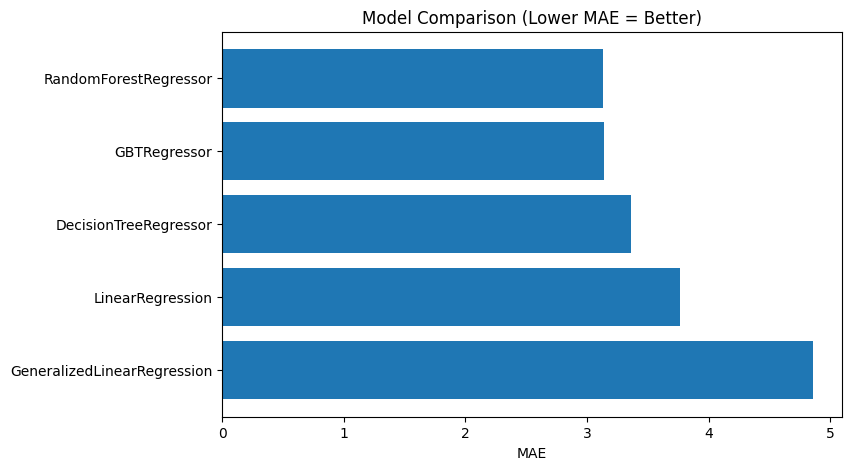

In [64]:
baseline_pdf = baseline_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(baseline_pdf["model_name"], baseline_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

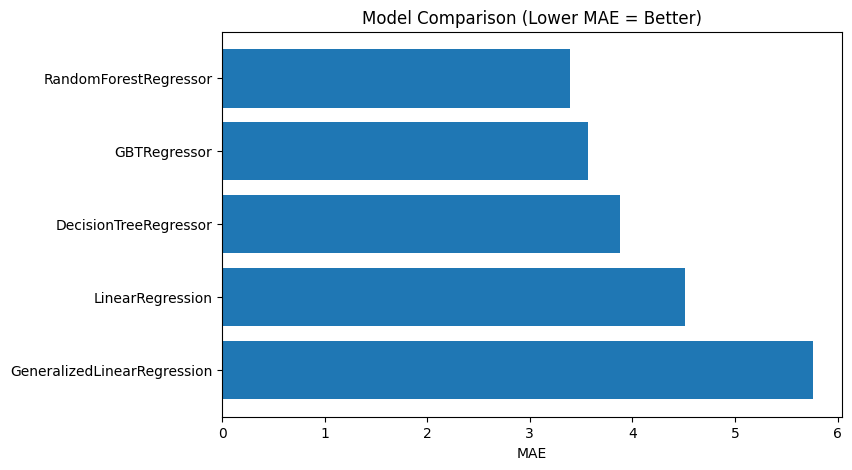

In [65]:
final_pdf = final_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(final_pdf["model_name"], final_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

##### 15. plot 

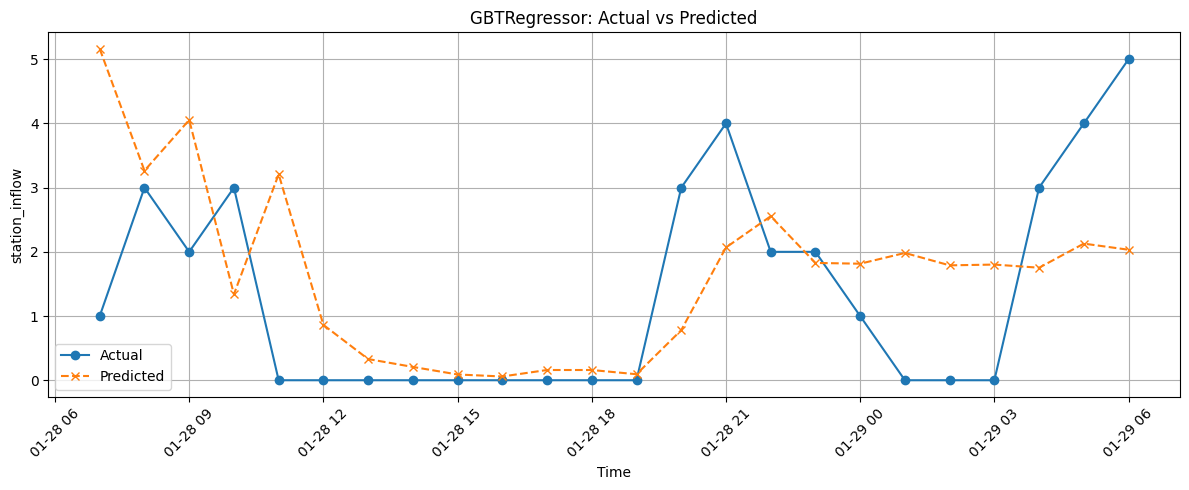

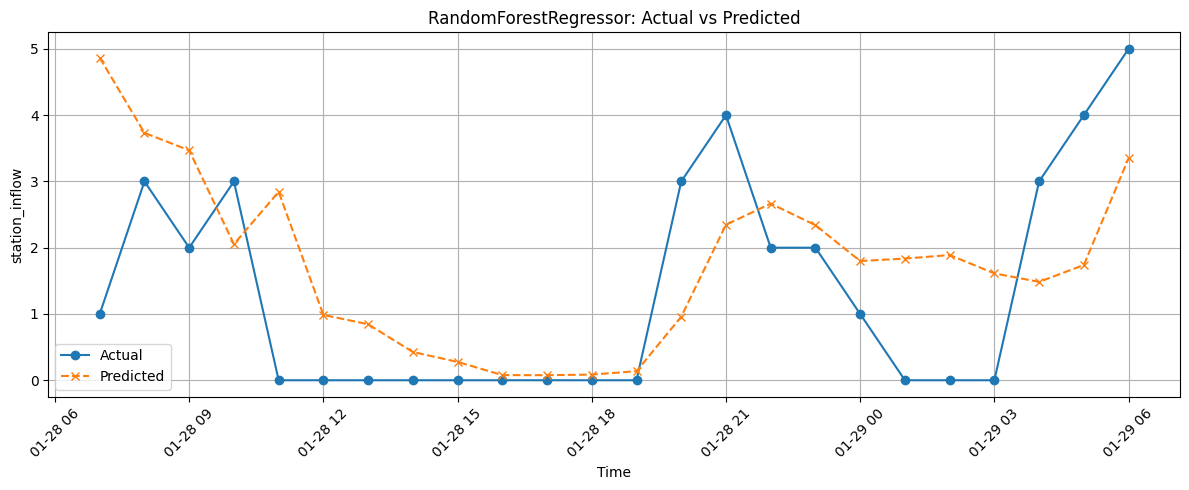

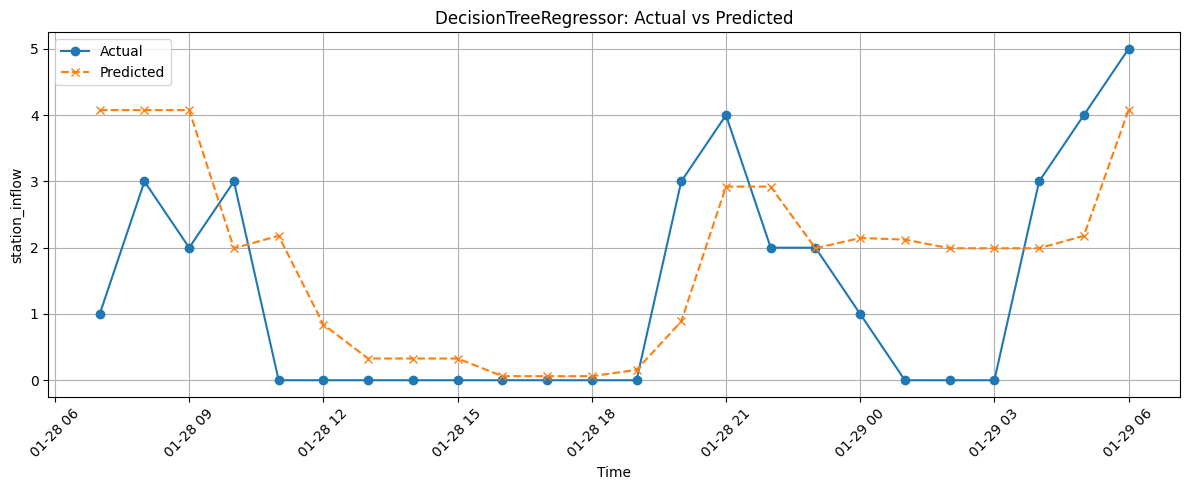

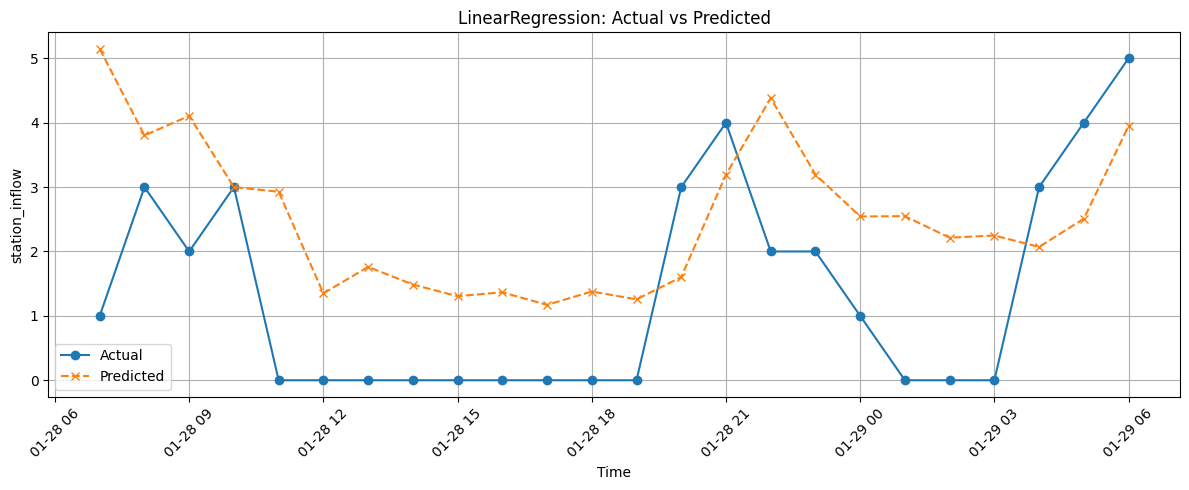

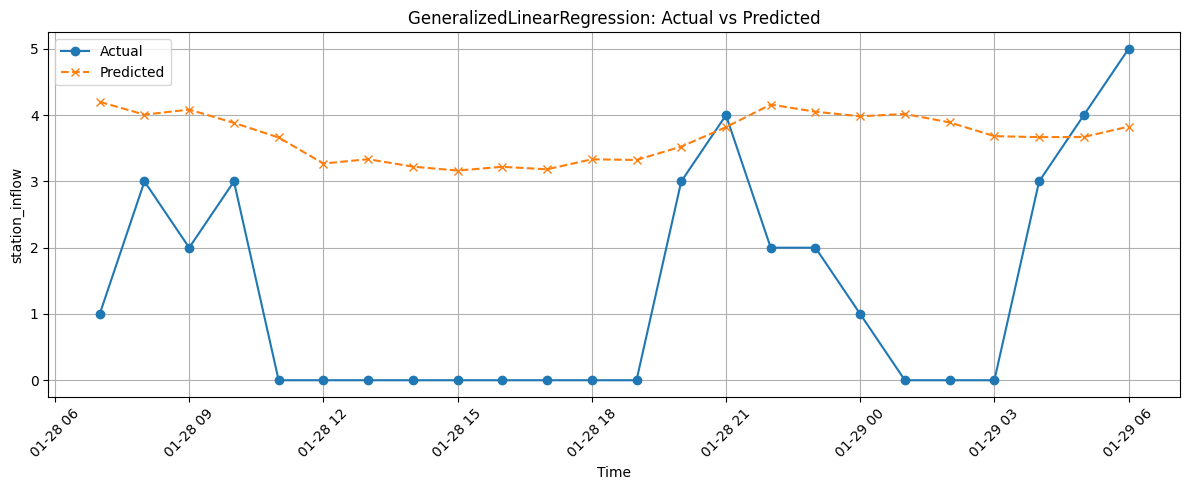

In [66]:
### plot baseline results 
for result in baseline_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

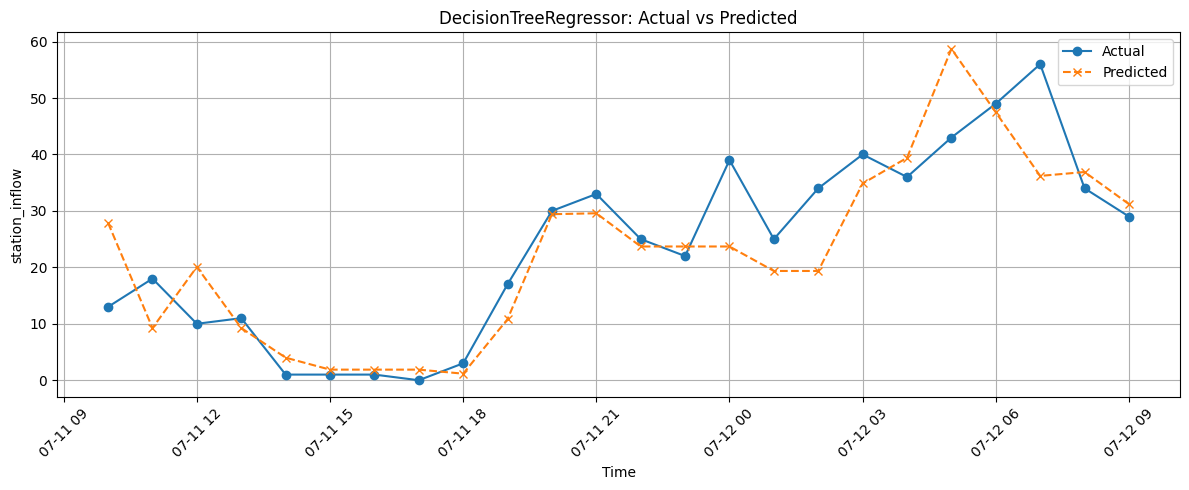

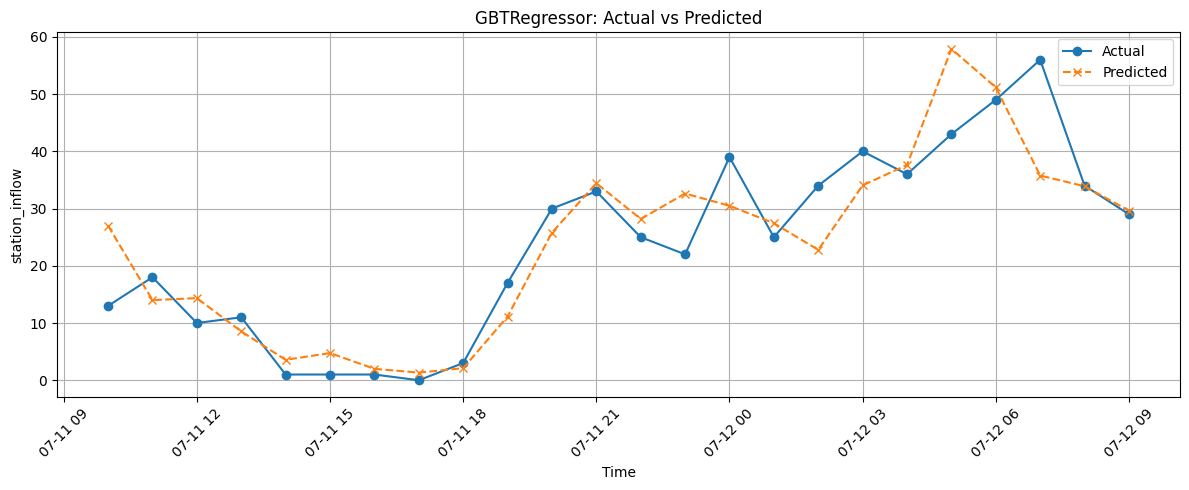

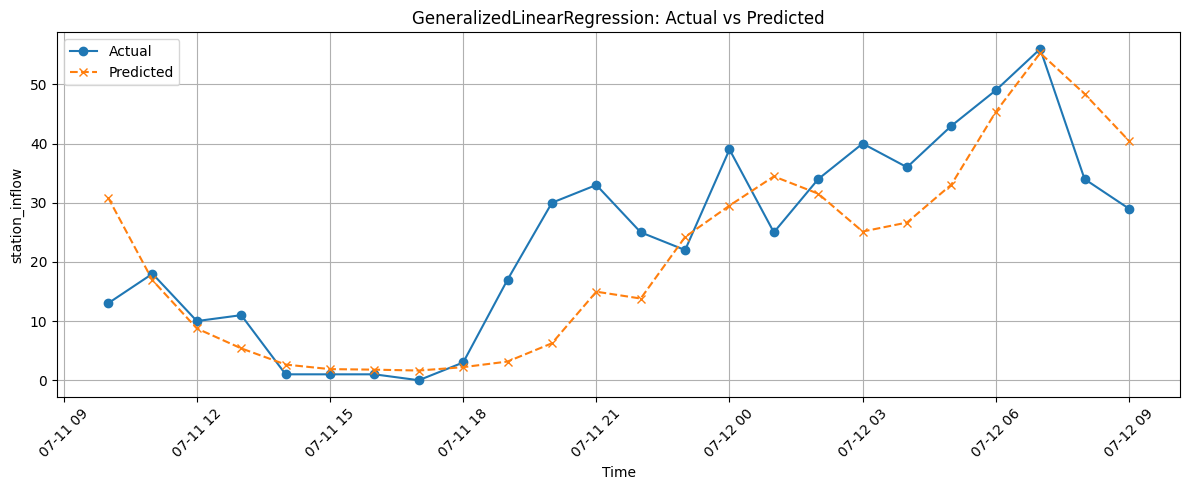

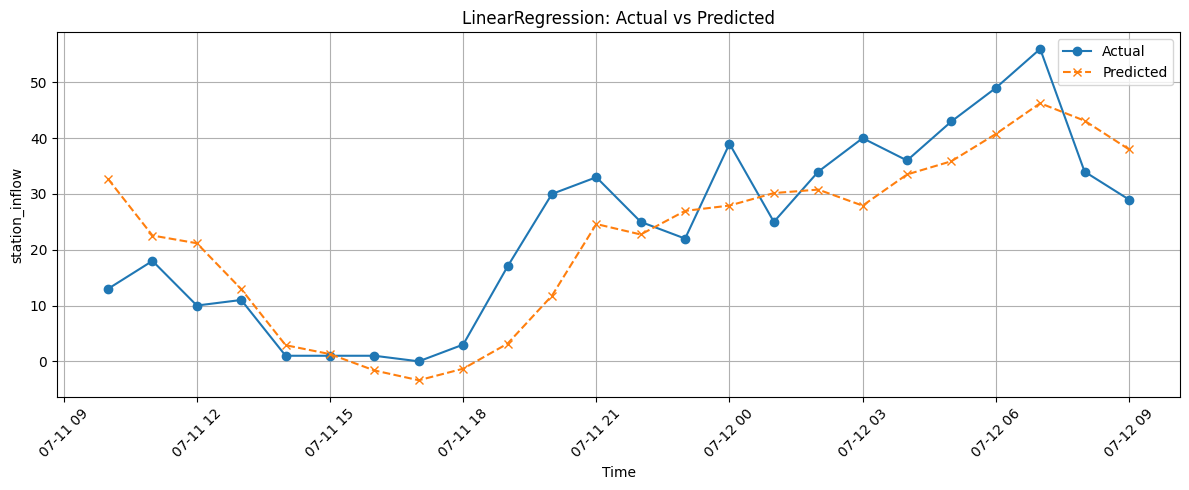

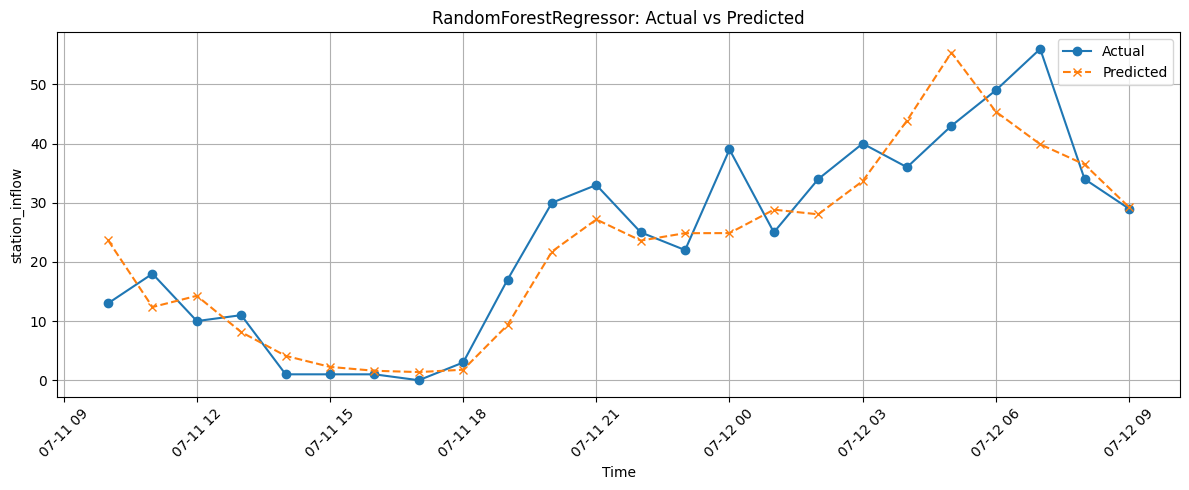

In [67]:
### plot final results 
for result in final_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Saving the best trained INFLOW model

In [68]:
best_inflowModeling_result = min(final_results, key=lambda x: x["mae"])

best_inflow_model_name = best_inflowModeling_result["model_name"]
best_inflow_model = best_inflowModeling_result["fitted_model"]

print("Best model:", best_inflow_model_name)
print("MAE:", best_inflowModeling_result["mae"])
print("RMSE:", best_inflowModeling_result["rmse"])
print("R2:", best_inflowModeling_result["r2"])

Best model: RandomForestRegressor
MAE: 3.3933704104866536
RMSE: 5.353734187137503
R2: 0.8809739752889212


In [69]:
# save_path = f"outputModels/best_inflow_model_{best_inflow_model_name}"
# best_inflow_model.write().overwrite().save(save_path)
# print(f"Model saved to: {save_path}")

In [70]:
"""saving all inflow models"""
# Save all trained inflow models, not just the best one
inflow_model_save_root = "outputModels_all/inflow_models"
os.makedirs(inflow_model_save_root, exist_ok=True)

saved_inflow_paths = []

for idx, result in enumerate(final_results, start=1):
    model_name = result["model_name"]
    fitted_model = result["fitted_model"]
    safe_model_name = re.sub(r"[^A-Za-z0-9_\-]+", "_", model_name)
    save_path = f"{inflow_model_save_root}/{idx:02d}_{safe_model_name}"

    fitted_model.write().overwrite().save(save_path)

    saved_inflow_paths.append({
        "rank_order": idx,
        "model_name": model_name,
        "save_path": save_path,
        "mae": result["mae"],
        "rmse": result["rmse"],
        "r2": result["r2"],
    })

saved_inflow_paths_pdf = pd.DataFrame(saved_inflow_paths).sort_values(["mae", "rmse"])
print(f"Saved {len(saved_inflow_paths)} inflow models to: {inflow_model_save_root}")
saved_inflow_paths_pdf

26/04/18 11:29:48 WARN TaskSetManager: Stage 5508 contains a task of very large size (6015 KiB). The maximum recommended task size is 1000 KiB.


Saved 5 inflow models to: outputModels_all/inflow_models


,rank_order,model_name,save_path,mae,rmse,r2
4,5,RandomForestRegressor,outputModels_all/inflow_models/05_RandomForest...,3.393370,5.353734,0.880974
1,2,GBTRegressor,outputModels_all/inflow_models/02_GBTRegressor,3.568657,5.696452,0.865247
0,1,DecisionTreeRegressor,outputModels_all/inflow_models/01_DecisionTree...,3.875893,6.149807,0.842945
3,4,LinearRegression,outputModels_all/inflow_models/04_LinearRegres...,4.508410,6.854461,0.804892
2,3,GeneralizedLinearRegression,outputModels_all/inflow_models/03_GeneralizedL...,5.756897,13.649480,0.226322


## Outflow modeling: exploratory diagnostics

feature importance

In [71]:
ALL_COLUMNS = ['ts_hour', 'station_inflow', 'station_outflow', 'station_netflow', 'radius100m_inflow_lag1', 'radius100m_outflow_lag1', 'radius100m_inflow_lag12', 'radius100m_outflow_lag12', 'radius100m_inflow_rollmean6', 'radius100m_outflow_rollmean6', 'radius100m_inflow_rollmean12', 'radius100m_outflow_rollmean12', 'radius100m_inflow_rollsum6', 'radius100m_outflow_rollsum6', 'radius100m_inflow_rollsum12', 'radius100m_outflow_rollsum12', 'radius200m_inflow_lag1', 'radius200m_outflow_lag1', 'radius200m_inflow_lag12', 'radius200m_outflow_lag12', 'radius200m_inflow_rollmean6', 'radius200m_outflow_rollmean6', 'radius200m_inflow_rollmean12', 'radius200m_outflow_rollmean12', 'radius200m_inflow_rollsum6', 'radius200m_outflow_rollsum6', 'radius200m_inflow_rollsum12', 'radius200m_outflow_rollsum12', 'radius500m_inflow_lag1', 'radius500m_outflow_lag1', 'radius500m_inflow_lag12', 'radius500m_outflow_lag12', 'radius500m_inflow_rollmean6', 'radius500m_outflow_rollmean6', 'radius500m_inflow_rollmean12', 'radius500m_outflow_rollmean12', 'radius500m_inflow_rollsum6', 'radius500m_outflow_rollsum6', 'radius500m_inflow_rollsum12', 'radius500m_outflow_rollsum12', 'temp', 'precip', 'station_inflow_lag1', 'station_outflow_lag1', 'station_inflow_lag12', 'station_outflow_lag12', 'precip_rollmean3', 'station_inflow_rollmean6', 'station_outflow_rollmean6', 'station_inflow_rollmean12', 'station_outflow_rollmean12', 'precip_rollsum3', 'station_inflow_rollsum6', 'station_outflow_rollsum6', 'station_inflow_rollsum12', 'station_outflow_rollsum12', 'temp_bin', 'dow', 'is_weekday', 'hod', 'moy', 'dow_cos', 'hod_cos', 'moy_cos']

TIME_COL = "ts_hour"
TARGET_COL = "station_outflow"   # change to station_outflow or station_netflow as needed

# features to exclude from predictors
BASE_EXCLUDE = [TIME_COL, "station_inflow", "station_outflow", "station_netflow"]

# categorical columns detected from your schema preview
CATEGORICAL_COLS = ["temp_bin"]

# boolean columns
BOOLEAN_COLS = ["is_weekday"]

# numeric columns inferred from your schema preview
NUMERIC_COLS = [c for c in ALL_COLUMNS if c not in BASE_EXCLUDE + CATEGORICAL_COLS + BOOLEAN_COLS]

print("Target:", TARGET_COL)
print("Numeric feature count:", len(NUMERIC_COLS))
print("Categorical feature count:", len(CATEGORICAL_COLS))
print("Boolean feature count:", len(BOOLEAN_COLS))

Target: station_outflow
Numeric feature count: 58
Categorical feature count: 1
Boolean feature count: 1


In [72]:
# fill numeric nulls with 0 for a stable exploratory screen
fill_map = {c: 0.0 for c in NUMERIC_COLS}
fill_map.update({c: 0 for c in BOOLEAN_COLS})

screen_df = gold_0001_df.fillna(fill_map)

# string index + one-hot encode temp_bin
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in CATEGORICAL_COLS]

screen_feature_inputs = NUMERIC_COLS + BOOLEAN_COLS + [f"{c}_ohe" for c in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=screen_feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

screen_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
screen_model = screen_pipe.fit(screen_df)
screen_ready = screen_model.transform(screen_df).select(TIME_COL, TARGET_COL, "features_raw", "features_scaled")
print("Exploratory screening rows:", screen_ready.count())

# helper to expand feature names after OHE
def get_feature_names_from_pipeline_model(pipeline_model, numeric_cols, boolean_cols, categorical_cols):
    feature_names = list(numeric_cols) + list(boolean_cols)
    for c in categorical_cols:
        idx_model = next(s for s in pipeline_model.stages if hasattr(s, 'getOutputCol') and s.getOutputCol() == f"{c}_idx")
        labels = list(idx_model.labels) + ["__unknown__"]
        drop_last = True  # default behavior of Spark OHE
        usable = labels[:-1] if drop_last and len(labels) > 1 else labels
        feature_names.extend([f"{c}={lab}" for lab in usable])
    return feature_names

screen_feature_names = get_feature_names_from_pipeline_model(screen_model, NUMERIC_COLS, BOOLEAN_COLS, CATEGORICAL_COLS)
len(screen_feature_names), screen_feature_names[:10]

Exploratory screening rows: 24614


(68,
 ['radius100m_inflow_lag1',
  'radius100m_outflow_lag1',
  'radius100m_inflow_lag12',
  'radius100m_outflow_lag12',
  'radius100m_inflow_rollmean6',
  'radius100m_outflow_rollmean6',
  'radius100m_inflow_rollmean12',
  'radius100m_outflow_rollmean12',
  'radius100m_inflow_rollsum6',
  'radius100m_outflow_rollsum6'])

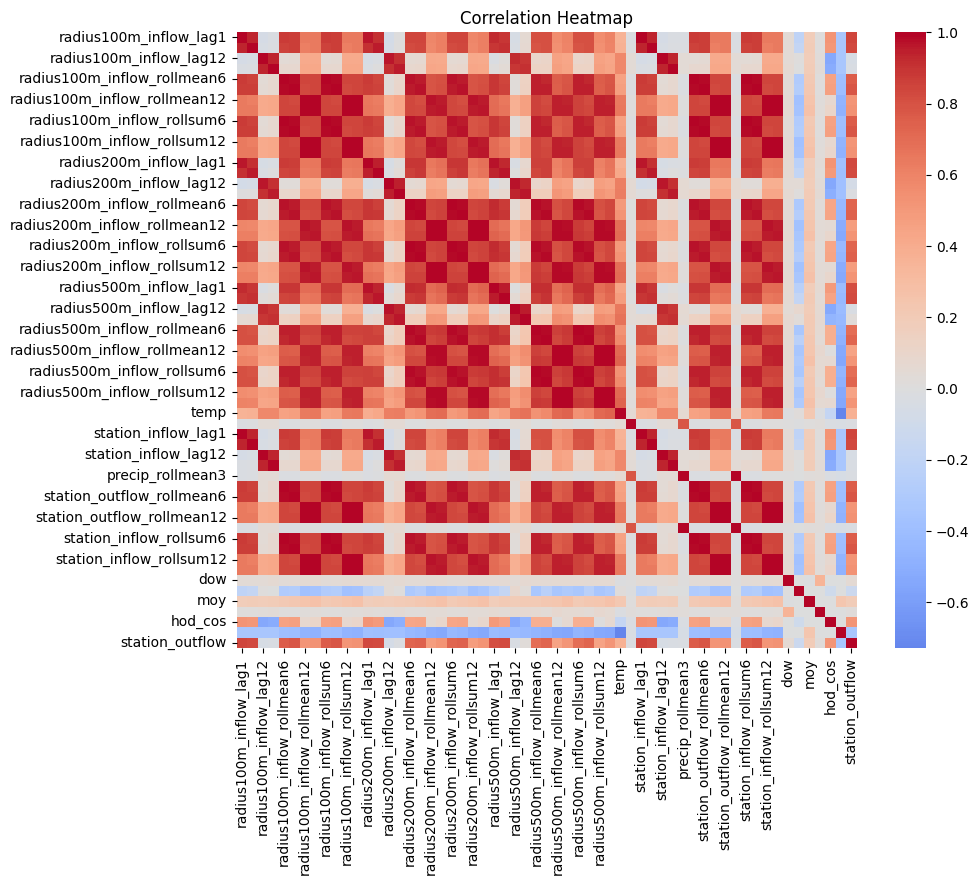

In [73]:
pdf = screen_df.select(NUMERIC_COLS + [TARGET_COL]).toPandas()
plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

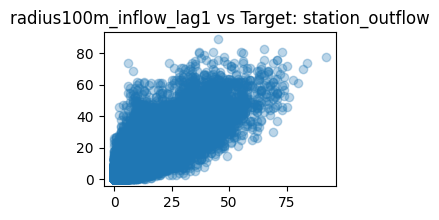

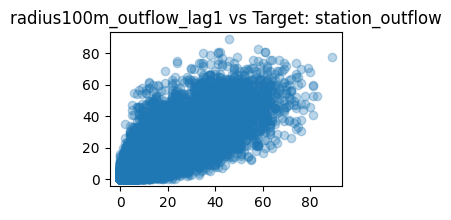

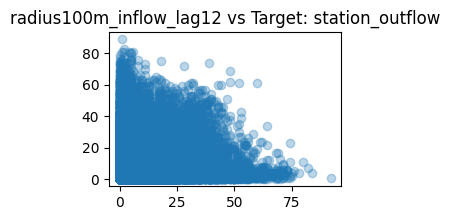

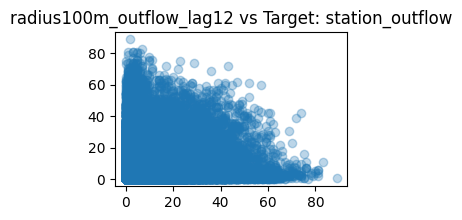

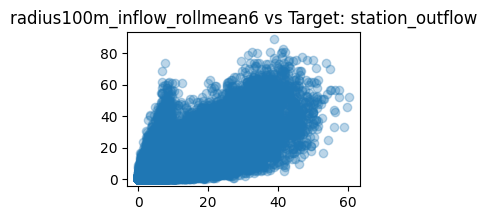

In [74]:
for col in NUMERIC_COLS[:5]:
    plt.figure(figsize=(3, 2))
    plt.scatter(pdf[col], pdf[TARGET_COL], alpha=0.3)
    plt.title(f"{col} vs Target: {TARGET_COL}")
    plt.show()

In [75]:
SCREEN_TOP_K = 25

outflow_screen_ctx = run_exploratory_univariate_screen(
    source_df=gold_0001_df,
    target_col=TARGET_COL,
    time_col=TIME_COL,
    numeric_cols=NUMERIC_COLS,
    boolean_cols=BOOLEAN_COLS,
    categorical_cols=CATEGORICAL_COLS,
    top_k=SCREEN_TOP_K
)

screen_ready = outflow_screen_ctx["screen_ready"]
screen_feature_names = outflow_screen_ctx["screen_feature_names"]
screen_selected_feature_indices = outflow_screen_ctx["selected_feature_indices"]
screen_selected_features = outflow_screen_ctx["selected_features"]
ufs_screen_pdf = outflow_screen_ctx["selection_pdf"]

print("Exploratory screening rows:", screen_ready.count())
print("UnivariateFeatureSelector shortlisted features:", len(screen_selected_features))
ufs_screen_pdf.head(20)

Exploratory screening rows: 24614
UnivariateFeatureSelector shortlisted features: 25


,rank,feature_index,feature
0,1,0,radius100m_inflow_lag1
1,2,1,radius100m_outflow_lag1
2,3,2,radius100m_inflow_lag12
3,4,4,radius100m_inflow_rollmean6
4,5,5,radius100m_outflow_rollmean6
5,6,6,radius100m_inflow_rollmean12
6,7,7,radius100m_outflow_rollmean12
7,8,8,radius100m_inflow_rollsum6
8,9,9,radius100m_outflow_rollsum6
9,10,10,radius100m_inflow_rollsum12


In [76]:
# full shortlist from exploratory UnivariateFeatureSelector
ufs_screen_pdf

,rank,feature_index,feature
0,1,0,radius100m_inflow_lag1
1,2,1,radius100m_outflow_lag1
2,3,2,radius100m_inflow_lag12
3,4,4,radius100m_inflow_rollmean6
4,5,5,radius100m_outflow_rollmean6
5,6,6,radius100m_inflow_rollmean12
6,7,7,radius100m_outflow_rollmean12
7,8,8,radius100m_inflow_rollsum6
8,9,9,radius100m_outflow_rollsum6
9,10,10,radius100m_inflow_rollsum12


In [77]:
# keep the exploratory shortlist visible for reference
screen_top_union = list(screen_selected_features)
print('Shortlisted features:', len(screen_top_union))
screen_top_union[:20]

Shortlisted features: 25


['radius100m_inflow_lag1',
 'radius100m_outflow_lag1',
 'radius100m_inflow_lag12',
 'radius100m_inflow_rollmean6',
 'radius100m_outflow_rollmean6',
 'radius100m_inflow_rollmean12',
 'radius100m_outflow_rollmean12',
 'radius100m_inflow_rollsum6',
 'radius100m_outflow_rollsum6',
 'radius100m_inflow_rollsum12',
 'radius100m_outflow_rollsum12',
 'radius200m_inflow_lag1',
 'radius200m_outflow_lag1',
 'radius200m_inflow_lag12',
 'radius200m_inflow_rollmean6',
 'radius200m_outflow_rollmean6',
 'radius200m_inflow_rollmean12',
 'radius200m_outflow_rollmean12',
 'radius200m_inflow_rollsum6',
 'radius200m_outflow_rollsum6']

In [78]:
USE_SCREENED_FEATURES = True

outflow_prep_ctx = prepare_datasets_with_feature_selection(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=TARGET_COL,
    numeric_cols=NUMERIC_COLS,
    boolean_cols=BOOLEAN_COLS,
    categorical_cols=CATEGORICAL_COLS,
    use_screened_features=USE_SCREENED_FEATURES,
    selector_top_k=SCREEN_TOP_K
)

fill_map = outflow_prep_ctx["fill_map"]
prep_model = outflow_prep_ctx["prep_model"]
train_ready = outflow_prep_ctx["train_ready"]
val_ready = outflow_prep_ctx["val_ready"]
test_ready = outflow_prep_ctx["test_ready"]
TREE_FEATURES_COL = outflow_prep_ctx["tree_features_col"]
LINEAR_FEATURES_COL = outflow_prep_ctx["linear_features_col"]
model_feature_names = outflow_prep_ctx["model_feature_names"]
full_model_feature_names = outflow_prep_ctx["full_model_feature_names"]
selected_feature_indices = outflow_prep_ctx["selected_feature_indices"]
ufs_train_pdf = outflow_prep_ctx["selection_pdf"]

print("Using screened features:", USE_SCREENED_FEATURES)
print("Prepared feature count used downstream:", len(model_feature_names))
display(ufs_train_pdf.head(20))

Using screened features: True
Prepared feature count used downstream: 25


,rank,feature_index,feature
0,1,0,radius100m_inflow_lag1
1,2,1,radius100m_outflow_lag1
2,3,2,radius100m_inflow_lag12
3,4,3,radius100m_outflow_lag12
4,5,4,radius100m_inflow_rollmean6
5,6,5,radius100m_outflow_rollmean6
6,7,6,radius100m_inflow_rollmean12
7,8,7,radius100m_outflow_rollmean12
8,9,8,radius100m_inflow_rollsum6
9,10,9,radius100m_outflow_rollsum6


In [79]:
evaluator_specs = ["rmse", "mae", "r2"]

def evaluate_predictions(pred_df, label_col=TARGET_COL):
    out = {}
    for metric in evaluator_specs:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
        out[metric] = ev.evaluate(pred_df)
    return out

def fit_and_evaluate(model_name, estimator, train_data, eval_data, features_col):
    fitted = estimator.fit(train_data)
    pred = fitted.transform(eval_data)
    metrics = evaluate_predictions(pred, TARGET_COL)
    return {
        "model_name": model_name,
        "features_col": features_col,
        "fitted_model": fitted,
        "predictions": pred,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }

def extract_tree_importance(model, feature_names):
    if hasattr(model, "featureImportances"):
        return pd.DataFrame({
            "feature": feature_names,
            "importance": list(model.featureImportances.toArray())
        }).sort_values("importance", ascending=False)
    return None

def extract_linear_importance(model, feature_names):
    if hasattr(model, "coefficients"):
        pdf = pd.DataFrame({
            "feature": feature_names,
            "coefficient": list(model.coefficients.toArray())
        })
        pdf["abs_coefficient"] = pdf["coefficient"].abs()
        return pdf.sort_values("abs_coefficient", ascending=False)
    return None

#### Outflow modeling: training-only model interpretation

These cells are exploratory diagnostics and do not change the selected training features.

Model Training - To Try All types of Time Series Regression supported by Spark

In [80]:
baseline_models = {
    "GBTRegressor": GBTRegressor(
        featuresCol=TREE_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        maxDepth=5,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=1.0,
        seed=42
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol=TREE_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        numTrees=100,
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol=TREE_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "LinearRegression": LinearRegression(
        featuresCol=LINEAR_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.1,
        elasticNetParam=0.0
    ),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(
        featuresCol=LINEAR_FEATURES_COL,
        labelCol=TARGET_COL,
        predictionCol="prediction",
        family="poisson",
        link="log",
        maxIter=50,
        regParam=0.0
    )
}


In [81]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        print(f"Skipping {model_name} because Poisson GLR is not suitable for negative netflow targets.")
        continue

    features_col = estimator.getFeaturesCol()
    result = fit_and_evaluate(model_name, estimator, train_ready, val_ready, features_col)
    baseline_results.append(result)
    print(model_name, {k: result[k] for k in ['rmse', 'mae', 'r2']})

baseline_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in baseline_results
]).sort_values("rmse")

baseline_metrics_pdf

GBTRegressor {'rmse': 5.775130505118968, 'mae': 3.5746619745623742, 'r2': 0.8417405833497212}


26/04/18 11:30:43 WARN DAGScheduler: Broadcasting large task binary with size 1255.5 KiB
26/04/18 11:30:45 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/04/18 11:30:48 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
26/04/18 11:30:51 WARN DAGScheduler: Broadcasting large task binary with size 1135.8 KiB


RandomForestRegressor {'rmse': 5.6335771531331975, 'mae': 3.530890554529959, 'r2': 0.8494036493258073}
DecisionTreeRegressor {'rmse': 6.418863852020246, 'mae': 3.9318262591552573, 'r2': 0.8044930127548786}
LinearRegression {'rmse': 6.406974132163139, 'mae': 4.11061325473792, 'r2': 0.8052166206998872}


26/04/18 11:30:59 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:30:59 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:30:59 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:31:00 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:31:00 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:31:01 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:31:01 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:31:01 WARN Instrumentation: [f4601298] regParam is zero, which might cause numerical instability and overf

GeneralizedLinearRegression {'rmse': 8.095358636620027, 'mae': 5.3461048206291135, 'r2': 0.6890302518824662}


,model_name,features_col,rmse,mae,r2
1,RandomForestRegressor,features_selected_raw,5.633577,3.530891,0.849404
0,GBTRegressor,features_selected_raw,5.775131,3.574662,0.841741
3,LinearRegression,features_selected_scaled,6.406974,4.110613,0.805217
2,DecisionTreeRegressor,features_selected_raw,6.418864,3.931826,0.804493
4,GeneralizedLinearRegression,features_selected_scaled,8.095359,5.346105,0.689030


#### 12. Training-only feature importance after the baseline round


In [82]:
importance_tables = {}

for r in baseline_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        importance_tables[name] = extract_linear_importance(model, model_feature_names)

list(importance_tables.keys())

['GBTRegressor',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'LinearRegression',
 'GeneralizedLinearRegression']

In [83]:
"""inspect top 3 features from all regresssors' importance table"""

print(importance_tables['GBTRegressor'].head(3))
print(importance_tables['RandomForestRegressor'].head(3))
print(importance_tables['DecisionTreeRegressor'].head(3))
print(importance_tables['LinearRegression'].head(3))
print(importance_tables['GeneralizedLinearRegression'].head(3))

                    feature  importance
24  radius500m_outflow_lag1    0.323590
14  radius200m_inflow_lag12    0.082211
12   radius200m_inflow_lag1    0.074163
                    feature  importance
24  radius500m_outflow_lag1    0.274186
13  radius200m_outflow_lag1    0.228311
0    radius100m_inflow_lag1    0.098976
                    feature  importance
24  radius500m_outflow_lag1    0.637888
12   radius200m_inflow_lag1    0.113237
14  radius200m_inflow_lag12    0.046739
                         feature  coefficient  abs_coefficient
24       radius500m_outflow_lag1     4.072290         4.072290
9    radius100m_outflow_rollsum6     3.890074         3.890074
5   radius100m_outflow_rollmean6     3.888299         3.888299
                         feature  coefficient  abs_coefficient
17  radius200m_inflow_rollmean12   -84.356425        84.356425
21   radius200m_inflow_rollsum12    82.741657        82.741657
4    radius100m_inflow_rollmean6   -53.891203        53.891203


#### 13. Manual time-aware hyperparameter tuning

Tunes using:
- `train_df` for fitting
- `val_df` for model selection

Which respects chronological order.

In [84]:
param_grids = {
    "GBTRegressor": [
        {"maxIter": 50, "maxDepth": 4, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 5, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 6, "stepSize": 0.1, "maxBins": 32},
    ],
    "RandomForestRegressor": [
        {"numTrees": 80, "maxDepth": 6, "maxBins": 32},
        {"numTrees": 120, "maxDepth": 8, "maxBins": 32},
        {"numTrees": 150, "maxDepth": 10, "maxBins": 64},
    ],
    "DecisionTreeRegressor": [
        {"maxDepth": 5, "maxBins": 32},
        {"maxDepth": 8, "maxBins": 32},
        {"maxDepth": 10, "maxBins": 64},
    ],
    "LinearRegression": [
        {"maxIter": 100, "regParam": 0.0, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.5},
        {"maxIter": 150, "regParam": 0.2, "elasticNetParam": 1.0},
    ],
    "GeneralizedLinearRegression": [
        {"maxIter": 50, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.1},
    ],
}


def build_estimator(model_name, params):
    if model_name == "GBTRegressor":
        return GBTRegressor(
            featuresCol=TREE_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, subsamplingRate=1.0, **params
        )
    if model_name == "RandomForestRegressor":
        return RandomForestRegressor(
            featuresCol=TREE_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(
            featuresCol=TREE_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "LinearRegression":
        return LinearRegression(
            featuresCol=LINEAR_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            **params
        )
    if model_name == "GeneralizedLinearRegression":
        return GeneralizedLinearRegression(
            featuresCol=LINEAR_FEATURES_COL, labelCol=TARGET_COL, predictionCol="prediction",
            family="poisson", link="log", **params
        )
    raise ValueError("Unknown model")


In [85]:
tuning_rows = []

for model_name, grid in param_grids.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        continue

    print(f"\nTuning {model_name}")
    for params in grid:
        est = build_estimator(model_name, params)
        fitted = est.fit(train_ready)
        pred = fitted.transform(val_ready)
        metrics = evaluate_predictions(pred, TARGET_COL)

        row = {
            "model_name": model_name,
            "params_json": json.dumps(params, sort_keys=True),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        }
        tuning_rows.append(row)
        print(row)

tuning_pdf = pd.DataFrame(tuning_rows).sort_values(["model_name", "rmse"])
tuning_pdf


Tuning GBTRegressor
{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 4, "maxIter": 50, "stepSize": 0.05}', 'rmse': 5.8843384653261595, 'mae': 3.747035740665685, 'r2': 0.8356986069938974}
{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 5, "maxIter": 100, "stepSize": 0.05}', 'rmse': 5.802053938250677, 'mae': 3.6058875131110466, 'r2': 0.8402615453048022}


26/04/18 11:32:37 WARN DAGScheduler: Broadcasting large task binary with size 1001.5 KiB
26/04/18 11:32:37 WARN DAGScheduler: Broadcasting large task binary with size 1005.4 KiB
26/04/18 11:32:37 WARN DAGScheduler: Broadcasting large task binary with size 1008.0 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1008.5 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1009.5 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1010.3 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1012.7 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1017.3 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1020.2 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1020.7 KiB
26/04/18 11:32:38 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB
26/04/18 11:32:38 WAR

{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "maxIter": 100, "stepSize": 0.1}', 'rmse': 5.85639691614364, 'mae': 3.617473466100101, 'r2': 0.8372552597187048}

Tuning RandomForestRegressor


26/04/18 11:32:58 WARN DAGScheduler: Broadcasting large task binary with size 1050.9 KiB


{'model_name': 'RandomForestRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "numTrees": 80}', 'rmse': 5.972846345906875, 'mae': 3.749280563139432, 'r2': 0.8307188346920089}


...

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 50, "regParam": 0.0}', 'rmse': 8.095358636620027, 'mae': 5.3461048206291135, 'r2': 0.6890302518824662}


26/04/18 11:35:00 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:01 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:01 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:02 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:02 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:03 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:03 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:35:03 WARN Instrumentation: [26f8303d] regParam is zero, which might cause numerical instability and overf

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.0}', 'rmse': 8.095358622490822, 'mae': 5.346104816161066, 'r2': 0.689030252967966}


{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.1}', 'rmse': 8.130001575305048, 'mae': 5.455560707275858, 'r2': 0.686363055291748}


,model_name,params_json,rmse,mae,r2
7,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",6.418864,3.931826,0.804493
6,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 5}",6.529483,4.131868,0.797696
8,DecisionTreeRegressor,"{""maxBins"": 64, ""maxDepth"": 10}",6.583655,3.986491,0.794326
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",5.802054,3.605888,0.840262
2,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",5.856397,3.617473,0.837255
0,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 4, ""maxIter"": 50, ...",5.884338,3.747036,0.835699
14,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",8.095359,5.346105,0.689030
13,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",8.095359,5.346105,0.689030
15,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",8.130002,5.455561,0.686363
10,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",6.406974,4.110613,0.805217


In [86]:
best_params_pdf = tuning_pdf.sort_values("rmse").groupby("model_name", as_index=False).first()
best_params_pdf

,model_name,params_json,rmse,mae,r2
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",6.418864,3.931826,0.804493
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",5.802054,3.605888,0.840262
2,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",8.095359,5.346105,0.689030
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",6.406974,4.110613,0.805217
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",5.367786,3.368821,0.863279


#### 14. Retrain with best parameters on the full 80% training window, then evaluate on the untouched 20% test set

In [89]:
apply_full_prep = outflow_prep_ctx["apply_full_prep"]

train_full_ready = apply_full_prep(train_full_df)
test_ready = apply_full_prep(test_df)

final_results_outflow = []

for _, row in best_params_pdf.iterrows():
    model_name = row["model_name"]
    params = json.loads(row["params_json"])
    final_est = build_estimator(model_name, params)
    final_model = final_est.fit(train_full_ready)
    final_pred = final_model.transform(test_ready)
    final_metrics = evaluate_predictions(final_pred, TARGET_COL)

    final_results_outflow.append({
        "model_name": model_name,
        "params_json": json.dumps(params, sort_keys=True),
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"],
        "fitted_model": final_model,
        "predictions": final_pred,
    })

final_metrics_pdf_outflow = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in final_results_outflow
]).sort_values("rmse")

final_metrics_pdf_outflow

26/04/18 11:38:50 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:50 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:51 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:51 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:52 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:52 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:53 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 11:38:53 WARN Instrumentation: [cf24b138] regParam is zero, which might cause numerical instability and overf

,model_name,params_json,rmse,mae,r2
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",6.068236,3.947499,0.871404
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",6.359601,4.131459,0.858758
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",7.229947,4.610537,0.817453
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",7.801790,5.118766,0.787435
2,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",14.446777,6.604328,0.271137


In [90]:
"""getting the feature importance from the final models"""
final_importance_tables = {}

for r in final_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        final_importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        final_importance_tables[name] = extract_linear_importance(model, model_feature_names)

for name, pdf in final_importance_tables.items():
    print("\n", name)
    display(pdf.head(15))


 DecisionTreeRegressor


,feature,importance
24,radius500m_outflow_lag1,0.635009
23,radius500m_inflow_lag1,0.116570
0,radius100m_inflow_lag1,0.049640
12,radius200m_inflow_lag1,0.042611
14,radius200m_inflow_lag12,0.040531
6,radius100m_inflow_rollmean12,0.033526
17,radius200m_inflow_rollmean12,0.033108
4,radius100m_inflow_rollmean6,0.021469
13,radius200m_outflow_lag1,0.009720
18,radius200m_outflow_rollmean12,0.004819



 GBTRegressor


,feature,importance
24,radius500m_outflow_lag1,0.310697
23,radius500m_inflow_lag1,0.089930
14,radius200m_inflow_lag12,0.068884
4,radius100m_inflow_rollmean6,0.064401
0,radius100m_inflow_lag1,0.062162
17,radius200m_inflow_rollmean12,0.051563
6,radius100m_inflow_rollmean12,0.045985
12,radius200m_inflow_lag1,0.041755
2,radius100m_inflow_lag12,0.038566
3,radius100m_outflow_lag12,0.037029



 GeneralizedLinearRegression


,feature,coefficient,abs_coefficient
8,radius100m_inflow_rollsum6,220.919066,220.919066
4,radius100m_inflow_rollmean6,-220.041062,220.041062
5,radius100m_outflow_rollmean6,154.887127,154.887127
9,radius100m_outflow_rollsum6,-154.809857,154.809857
6,radius100m_inflow_rollmean12,112.746862,112.746862
10,radius100m_inflow_rollsum12,-112.397939,112.397939
15,radius200m_inflow_rollmean6,109.809296,109.809296
19,radius200m_inflow_rollsum6,-109.648293,109.648293
17,radius200m_inflow_rollmean12,-84.403292,84.403292
21,radius200m_inflow_rollsum12,82.515246,82.515246



 LinearRegression


,feature,coefficient,abs_coefficient
8,radius100m_inflow_rollsum6,1546.122447,1546.122447
4,radius100m_inflow_rollmean6,-1534.651730,1534.651730
19,radius200m_inflow_rollsum6,-1296.064443,1296.064443
15,radius200m_inflow_rollmean6,1294.808034,1294.808034
6,radius100m_inflow_rollmean12,1184.263817,1184.263817
10,radius100m_inflow_rollsum12,-1176.504109,1176.504109
17,radius200m_inflow_rollmean12,-1122.624491,1122.624491
21,radius200m_inflow_rollsum12,1103.452508,1103.452508
5,radius100m_outflow_rollmean6,705.333601,705.333601
9,radius100m_outflow_rollsum6,-703.112273,703.112273



 RandomForestRegressor


,feature,importance
24,radius500m_outflow_lag1,0.212736
13,radius200m_outflow_lag1,0.201633
0,radius100m_inflow_lag1,0.146380
12,radius200m_inflow_lag1,0.085216
23,radius500m_inflow_lag1,0.078982
1,radius100m_outflow_lag1,0.075433
14,radius200m_inflow_lag12,0.028430
4,radius100m_inflow_rollmean6,0.025109
8,radius100m_inflow_rollsum6,0.022496
2,radius100m_inflow_lag12,0.016543


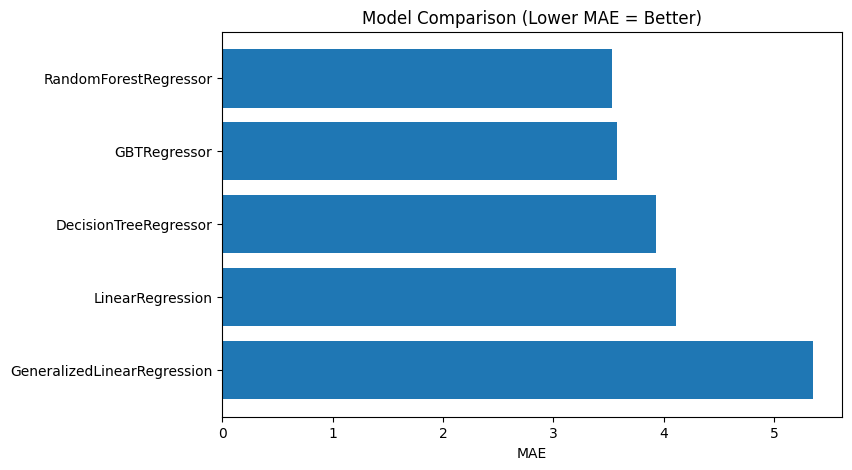

In [91]:
baseline_pdf = baseline_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(baseline_pdf["model_name"], baseline_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

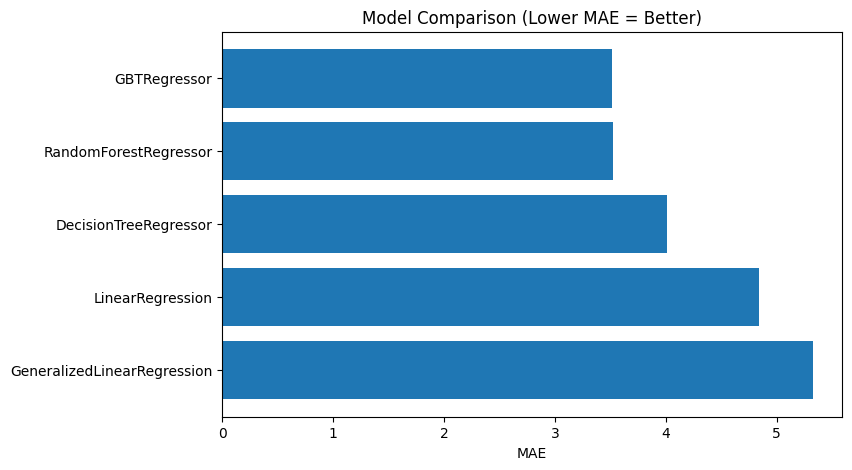

In [ ]:
final_pdf = final_metrics_pdf_outflow.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(final_pdf["model_name"], final_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

##### 15. plot 

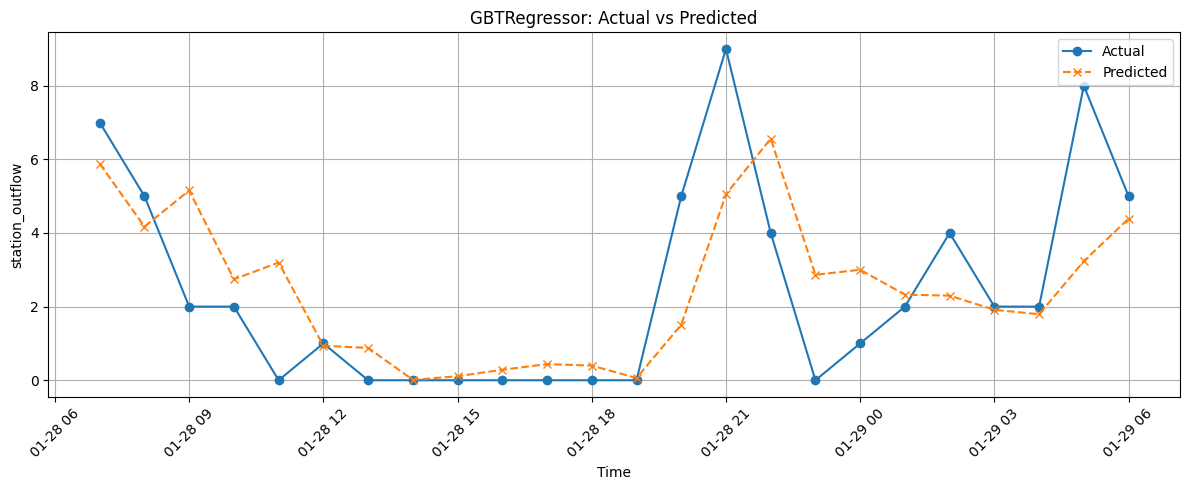

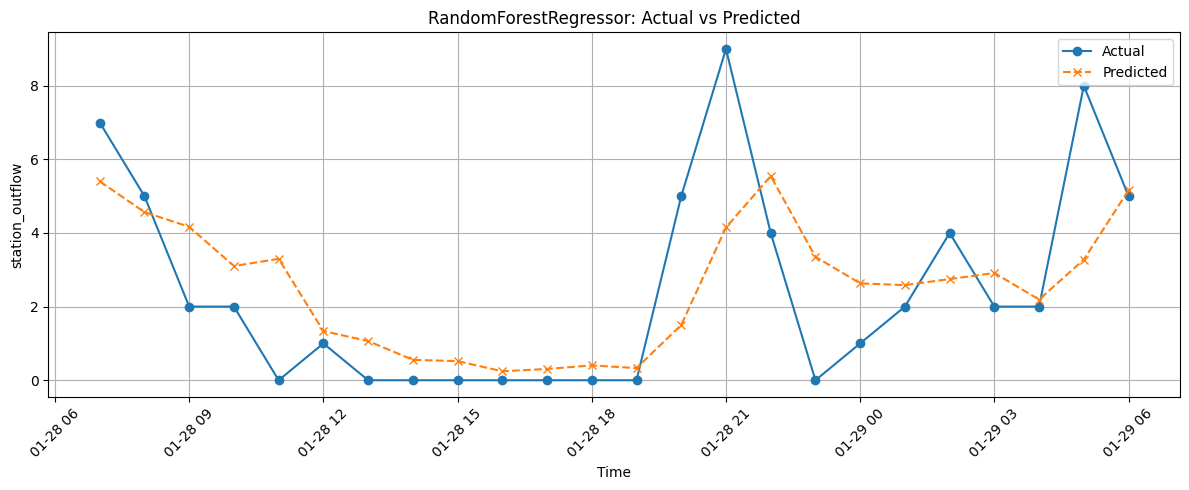

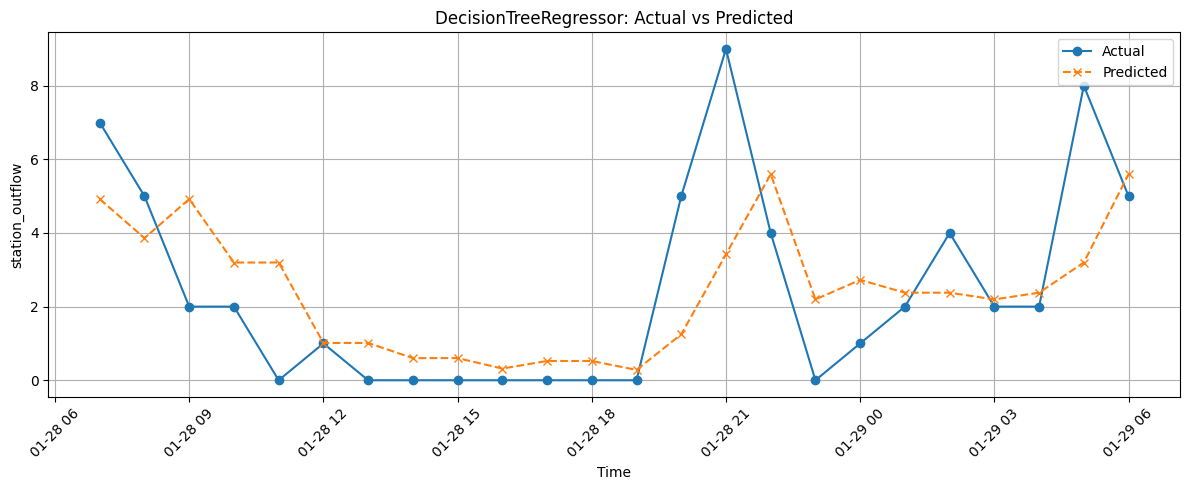

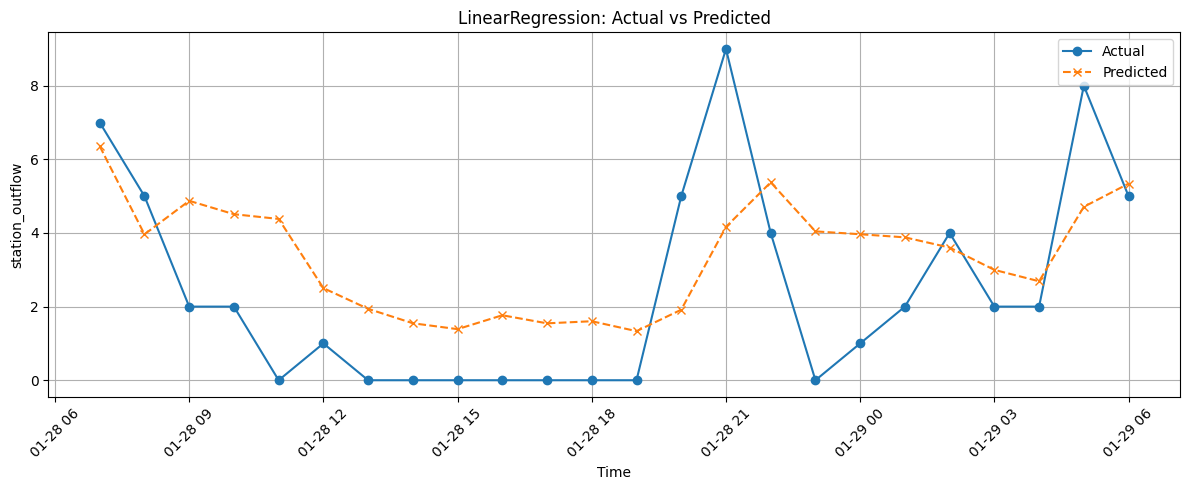

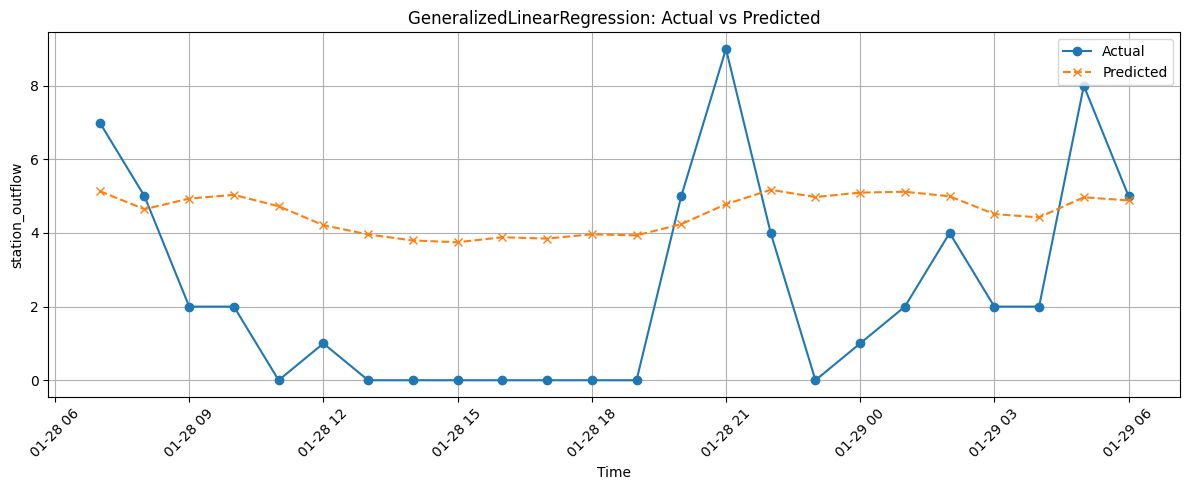

In [92]:
### plot baseline results 
for result in baseline_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

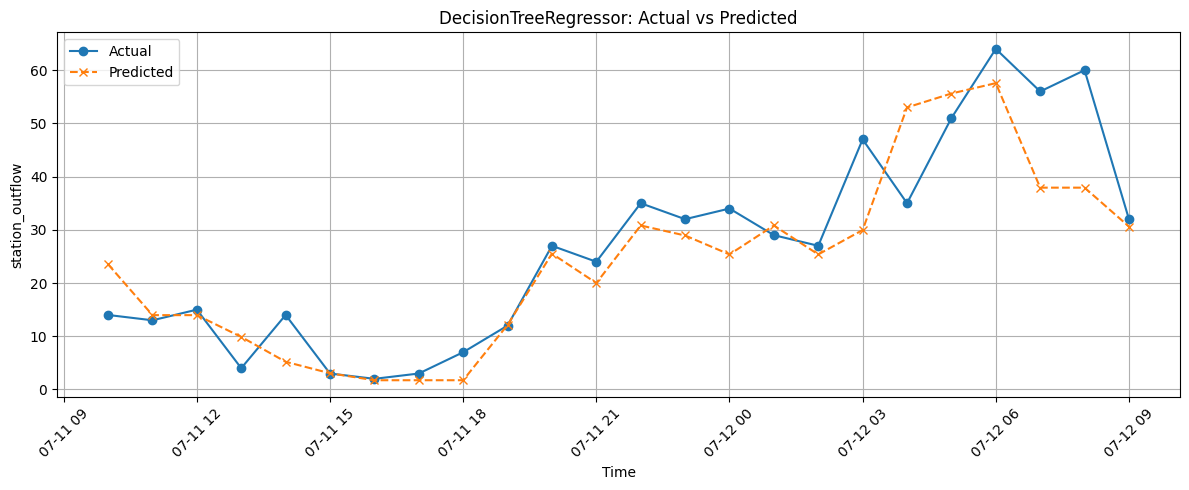

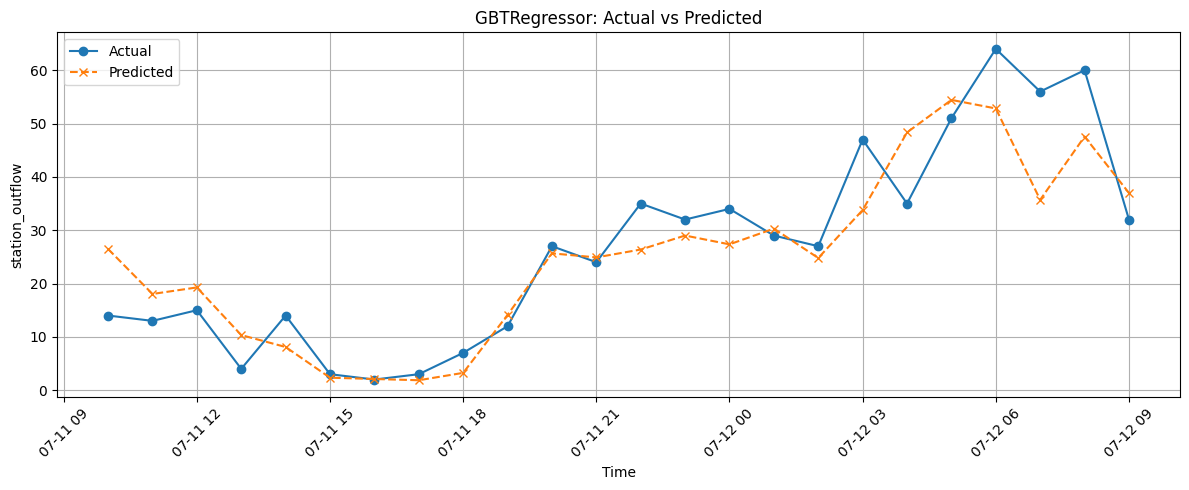

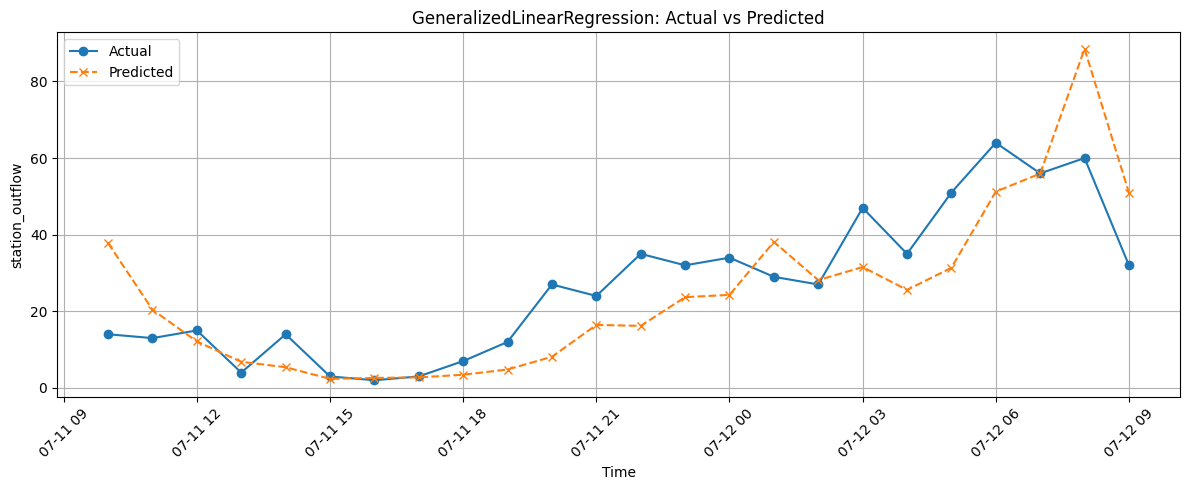

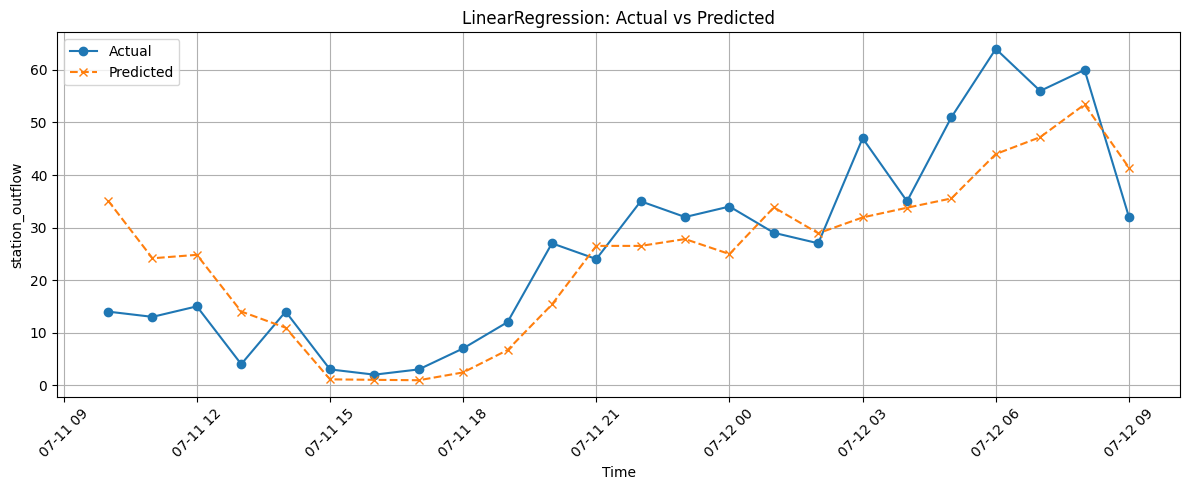

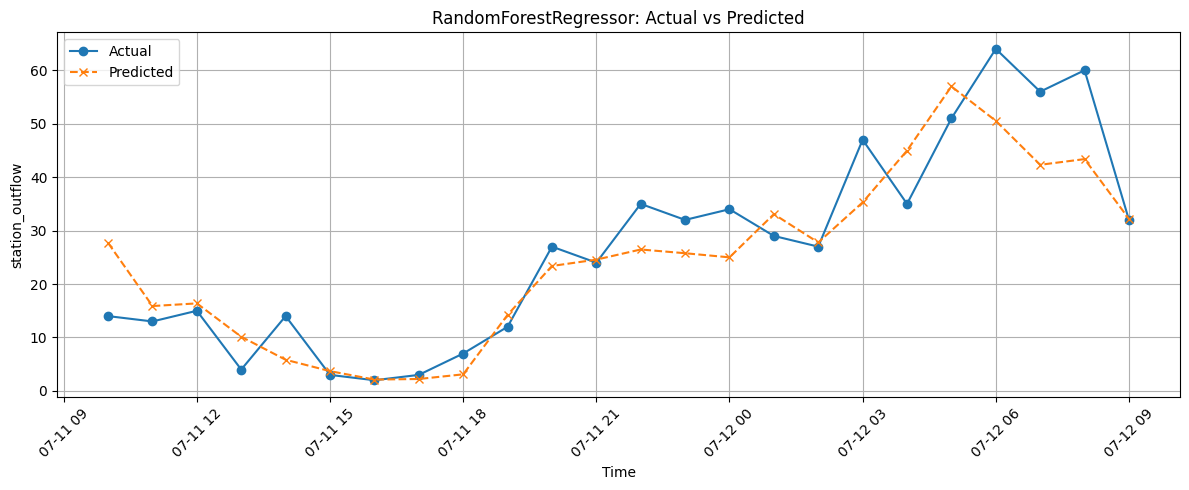

In [93]:
### plot final results 
for result in final_results_outflow:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Saving the best trained OUTFLOW model

In [94]:
best_outflowModeling_result = min(final_results_outflow, key=lambda x: x["mae"])

best_outflow_model_name = best_outflowModeling_result["model_name"]
best_outflow_model = best_outflowModeling_result["fitted_model"]

print("Best model:", best_outflow_model_name)
print("MAE:", best_outflowModeling_result["mae"])
print("RMSE:", best_outflowModeling_result["rmse"])
print("R2:", best_outflowModeling_result["r2"])

Best model: RandomForestRegressor
MAE: 3.947498781843942
RMSE: 6.068235946210375
R2: 0.8714035675726656


In [ ]:
# save_path = f"outputModels/best_outflow_model_{best_outflow_model_name}"
# best_outflow_model.write().overwrite().save(save_path)
# print(f"Model saved to: {save_path}")

Model saved to: outputModels/best_outflow_model_GBTRegressor


In [95]:
"""saving all models"""

# Save all trained outflow models, not just the best one
outflow_model_save_root = "outputModels_all/outflow_models"
os.makedirs(outflow_model_save_root, exist_ok=True)

saved_outflow_paths = []

for idx, result in enumerate(final_results_outflow, start=1):
    model_name = result["model_name"]
    fitted_model = result["fitted_model"]
    safe_model_name = re.sub(r"[^A-Za-z0-9_\-]+", "_", model_name)
    save_path = f"{outflow_model_save_root}/{idx:02d}_{safe_model_name}"

    fitted_model.write().overwrite().save(save_path)

    saved_outflow_paths.append({
        "rank_order": idx,
        "model_name": model_name,
        "save_path": save_path,
        "mae": result["mae"],
        "rmse": result["rmse"],
        "r2": result["r2"],
    })

saved_outflow_paths_pdf = pd.DataFrame(saved_outflow_paths).sort_values(["mae", "rmse"])
print(f"Saved {len(saved_outflow_paths)} outflow models to: {outflow_model_save_root}")
saved_outflow_paths_pdf

26/04/18 11:42:23 WARN TaskSetManager: Stage 10825 contains a task of very large size (6015 KiB). The maximum recommended task size is 1000 KiB.


Saved 5 outflow models to: outputModels_all/outflow_models


,rank_order,model_name,save_path,mae,rmse,r2
4,5,RandomForestRegressor,outputModels_all/outflow_models/05_RandomFores...,3.947499,6.068236,0.871404
1,2,GBTRegressor,outputModels_all/outflow_models/02_GBTRegressor,4.131459,6.359601,0.858758
0,1,DecisionTreeRegressor,outputModels_all/outflow_models/01_DecisionTre...,4.610537,7.229947,0.817453
3,4,LinearRegression,outputModels_all/outflow_models/04_LinearRegre...,5.118766,7.801790,0.787435
2,3,GeneralizedLinearRegression,outputModels_all/outflow_models/03_Generalized...,6.604328,14.446777,0.271137


## Notebook structure after refactor

- The exploratory cells above remain for diagnostics only.
- The reusable helper functions now own feature preparation and univariate selection.
- The selected feature subset is sliced into both tree and linear feature vectors, so downstream training uses the reduced set directly.
- The inflow and outflow paths both call the same preparation function, keeping the pipeline style closer to the repo script.

## Netflow evaluation on post-2025-08-01 test window

Use the final best trained inflow model and final best trained outflow model on the explicit holdout window where `ts_hour >= 2025-08-01`, then compute:

`model_netflow = model_inflow - model_outflow`

Evaluate this against `station_netflow`, including the custom asymmetric loss from `yc__loss_func.py`.


In [ ]:
from pyspark.ml.regression import RandomForestRegressionModel, GBTRegressionModel

best_inflow_model = RandomForestRegressionModel.load(
    "./outputModels/best_inflow_model_RandomForestRegressor"
)
best_outflow_model = GBTRegressionModel.load(
    "./outputModels/best_outflow_model_GBTRegressor"
)


26/04/18 11:42:34 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: outputModels/best_inflow_model_RandomForestRegressor/metadata.
java.io.FileNotFoundException: File outputModels/best_inflow_model_RandomForestRegressor/metadata does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSo

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/Users/user/Downloads/MTECH2526/EBA5006_project/bixi-analytics/EDA_and_modeling/outputModels/best_inflow_model_RandomForestRegressor/metadata. SQLSTATE: 42K03

26/04/18 11:53:40 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 122785 ms exceeds timeout 120000 ms
26/04/18 11:53:40 WARN SparkContext: Killing executors is not supported by current scheduler.
26/04/18 11:53:42 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
outflow_pred_df

NameError: name 'outflow_pred_df' is not defined

26/04/18 11:55:12 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:356)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1941

In [ ]:

# Build an explicit cutoff-based test input: all rows on/after 2025-08-01
cutoff_date = "2025-08-01"

cutoff_train_df = gold_0001_df.filter(F.col("ts_hour") < F.lit(cutoff_date))
cutoff_test_df = gold_0001_df.filter(F.col("ts_hour") >= F.lit(cutoff_date))

cutoff_fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
cutoff_fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

cutoff_train_df = cutoff_train_df.fillna(cutoff_fill_map)
cutoff_test_df = cutoff_test_df.fillna(cutoff_fill_map)

cutoff_indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in MODEL_CATEGORICAL_COLS
]
cutoff_encoders = [
    OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"])
    for c in MODEL_CATEGORICAL_COLS
]

cutoff_feature_inputs = (
    MODEL_NUMERIC_COLS
    + MODEL_BOOLEAN_COLS
    + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
)

cutoff_assembler = VectorAssembler(
    inputCols=cutoff_feature_inputs,
    outputCol="features_raw",
    handleInvalid="keep"
)
cutoff_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=False,
    withStd=True
)

cutoff_prep_pipe = Pipeline(stages=cutoff_indexers + cutoff_encoders + [cutoff_assembler, cutoff_scaler])
cutoff_prep_model = cutoff_prep_pipe.fit(cutoff_train_df)

cutoff_test_ready = cutoff_prep_model.transform(cutoff_test_df)

print(f"Cutoff date: {cutoff_date}")
print(f"Cutoff-train rows: {cutoff_train_df.count()}")
print(f"Cutoff-test rows: {cutoff_test_df.count()}")


Cutoff date: 2025-08-01
Cutoff-train rows: 20185
Cutoff-test rows: 4429


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

combo_metrics = []
best_netflow_output_df = None

for inflow_result in final_results:
    inflow_model_name = inflow_result["model_name"]
    inflow_pred_df = inflow_result["predictions"]

    for outflow_result in final_results_outflow:
        outflow_model_name = outflow_result["model_name"]
        outflow_pred_df = outflow_result["predictions"]

        inflow_sel = inflow_pred_df.select(
            "ts_hour",
            F.col(TARGET_COL).alias("actual_inflow"),
            F.col("prediction").alias("predicted_inflow")
        )

        outflow_sel = outflow_pred_df.select(
            "ts_hour",
            F.col(TARGET_COL).alias("actual_outflow"),
            F.col("prediction").alias("predicted_outflow")
        )

        combo_output_df = (
            inflow_sel.join(outflow_sel, on=["ts_hour"], how="inner")
            .withColumn("actual_netflow", F.col("actual_inflow") - F.col("actual_outflow"))
            .withColumn("predicted_netflow", F.col("predicted_inflow") - F.col("predicted_outflow"))
        )

        eval_df = combo_output_df.filter(
            F.col("actual_netflow").isNotNull() &
            F.col("predicted_netflow").isNotNull()
        )

        if eval_df.limit(1).count() == 0:
            continue

        rmse = RegressionEvaluator(
            labelCol="actual_netflow",
            predictionCol="predicted_netflow",
            metricName="rmse"
        ).evaluate(eval_df)

        mae = RegressionEvaluator(
            labelCol="actual_netflow",
            predictionCol="predicted_netflow",
            metricName="mae"
        ).evaluate(eval_df)

        r2 = RegressionEvaluator(
            labelCol="actual_netflow",
            predictionCol="predicted_netflow",
            metricName="r2"
        ).evaluate(eval_df)

        asymmetric_eval_df = (
            eval_df
            .withColumn(
                "asym_abs_error",
                F.when(
                    F.col("predicted_netflow") > F.col("actual_netflow"),
                    F.abs(F.col("predicted_netflow") - F.col("actual_netflow")) * 2.0
                ).otherwise(
                    F.abs(F.col("predicted_netflow") - F.col("actual_netflow"))
                )
            )
            .withColumn("asym_sq_error", F.pow(F.col("asym_abs_error"), 2))
        )

        asym_metrics = asymmetric_eval_df.agg(
            F.avg("asym_abs_error").alias("asymmetric_mae_mean"),
            F.sqrt(F.avg("asym_sq_error")).alias("asymmetric_rmse_mean")
        ).first()

        combo_metrics.append({
            "inflow_model": inflow_model_name,
            "outflow_model": outflow_model_name,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "asymmetric_mae_mean": asym_metrics["asymmetric_mae_mean"],
            "asymmetric_rmse_mean": asym_metrics["asymmetric_rmse_mean"]
        })

combo_metrics_pdf = pd.DataFrame(combo_metrics).sort_values(
    ["asymmetric_mae_mean", "asymmetric_rmse_mean", "mae", "rmse"],
    ascending=True
).reset_index(drop=True)

display(combo_metrics_pdf)

best_netflow_combo = combo_metrics_pdf.iloc[0].to_dict()
print("Best netflow combination:", best_netflow_combo)

,inflow_model,outflow_model,rmse,mae,r2,asymmetric_mae_mean,asymmetric_rmse_mean
0,RandomForestRegressor,RandomForestRegressor,3.120900,2.051080,-inf,2.120768,3.176934
1,GBTRegressor,RandomForestRegressor,3.673985,2.348450,-inf,2.686225,4.145032
2,RandomForestRegressor,GBTRegressor,3.977243,2.582414,-inf,2.819380,4.243233
3,LinearRegression,LinearRegression,3.669035,2.567966,-inf,2.838349,3.925568
4,GBTRegressor,GBTRegressor,4.093662,2.629427,-inf,3.009303,4.583251
5,RandomForestRegressor,DecisionTreeRegressor,4.490004,2.745083,-inf,3.131212,4.955968
6,DecisionTreeRegressor,RandomForestRegressor,4.517576,2.896932,-inf,3.233402,5.118950
7,GeneralizedLinearRegression,GeneralizedLinearRegression,5.690519,3.078276,-inf,3.357033,6.236847
8,GBTRegressor,DecisionTreeRegressor,4.747298,2.883976,-inf,3.458954,5.559188
9,DecisionTreeRegressor,GBTRegressor,5.062393,3.266388,-inf,3.689197,5.721692


Best netflow combination: {'inflow_model': 'RandomForestRegressor', 'outflow_model': 'RandomForestRegressor', 'rmse': 3.1209003135714366, 'mae': 2.0510801651925883, 'r2': -inf, 'asymmetric_mae_mean': 2.1207679207260304, 'asymmetric_rmse_mean': 3.176933671522588}


visualise the loss

In [ ]:
display(pivot_mae)

outflow_model,DecisionTreeRegressor,GBTRegressor,GeneralizedLinearRegression,LinearRegression,RandomForestRegressor
inflow_model,,,,,
DecisionTreeRegressor,3.885234,3.689197,6.094839,5.394467,3.233402
GBTRegressor,3.458954,3.009303,5.994955,5.158689,2.686225
GeneralizedLinearRegression,5.945200,5.706878,3.357033,5.763465,5.329721
LinearRegression,5.641599,5.373432,5.886398,2.838349,4.736188
RandomForestRegressor,3.131212,2.819380,5.489048,4.616526,2.120768


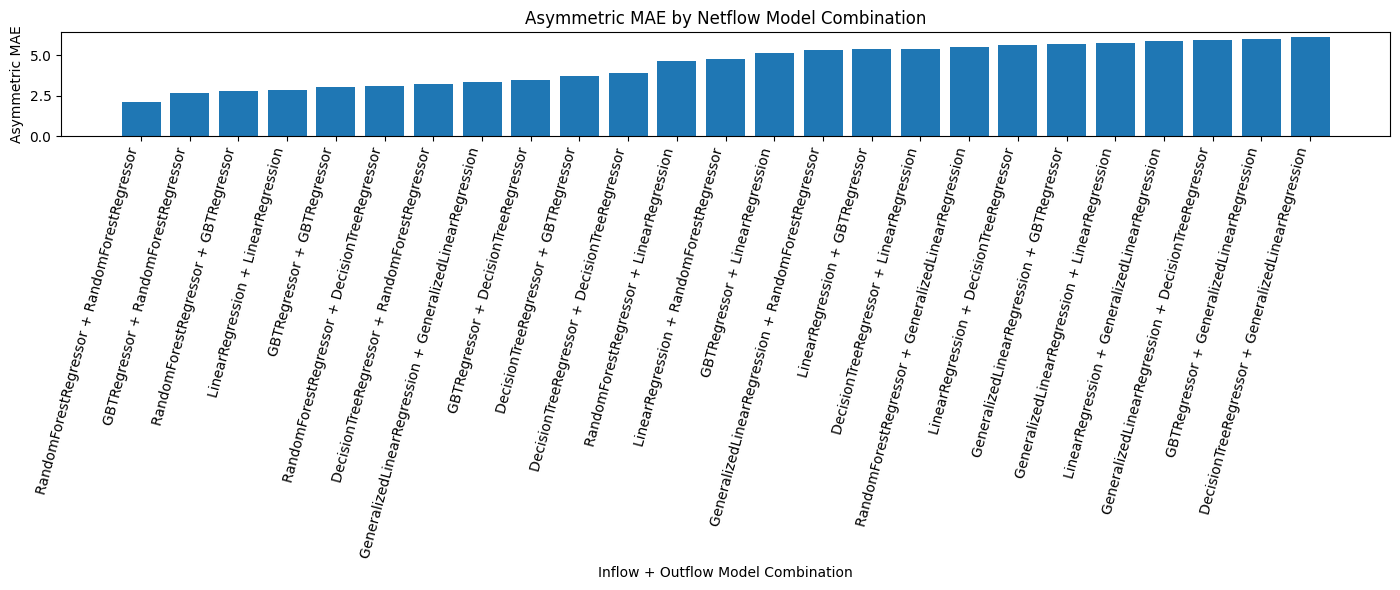

In [ ]:
combo_metrics_pdf["combo_name"] = (
    combo_metrics_pdf["inflow_model"] + " + " + combo_metrics_pdf["outflow_model"]
)

plot_df = combo_metrics_pdf.sort_values("asymmetric_mae_mean", ascending=True)

plt.figure(figsize=(14, 6))
plt.bar(plot_df["combo_name"], plot_df["asymmetric_mae_mean"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Asymmetric MAE")
plt.xlabel("Inflow + Outflow Model Combination")
plt.title("Asymmetric MAE by Netflow Model Combination")
plt.tight_layout()
plt.show()

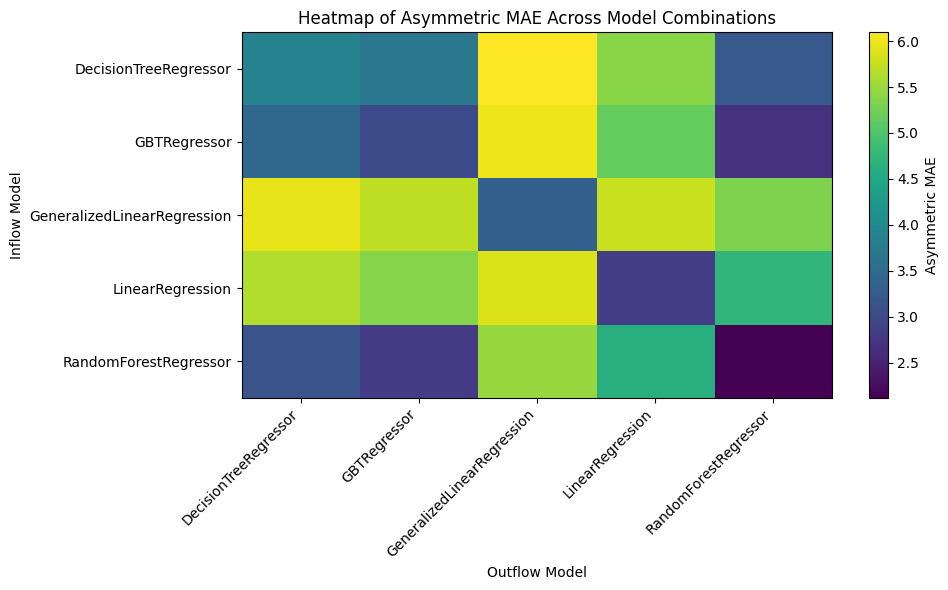

In [ ]:
pivot_mae = combo_metrics_pdf.pivot(
    index="inflow_model",
    columns="outflow_model",
    values="asymmetric_mae_mean"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_mae, aspect="auto")
plt.colorbar(label="Asymmetric MAE")
plt.xticks(range(len(pivot_mae.columns)), pivot_mae.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_mae.index)), pivot_mae.index)
plt.xlabel("Outflow Model")
plt.ylabel("Inflow Model")
plt.title("Heatmap of Asymmetric MAE Across Model Combinations")
plt.tight_layout()
plt.show()

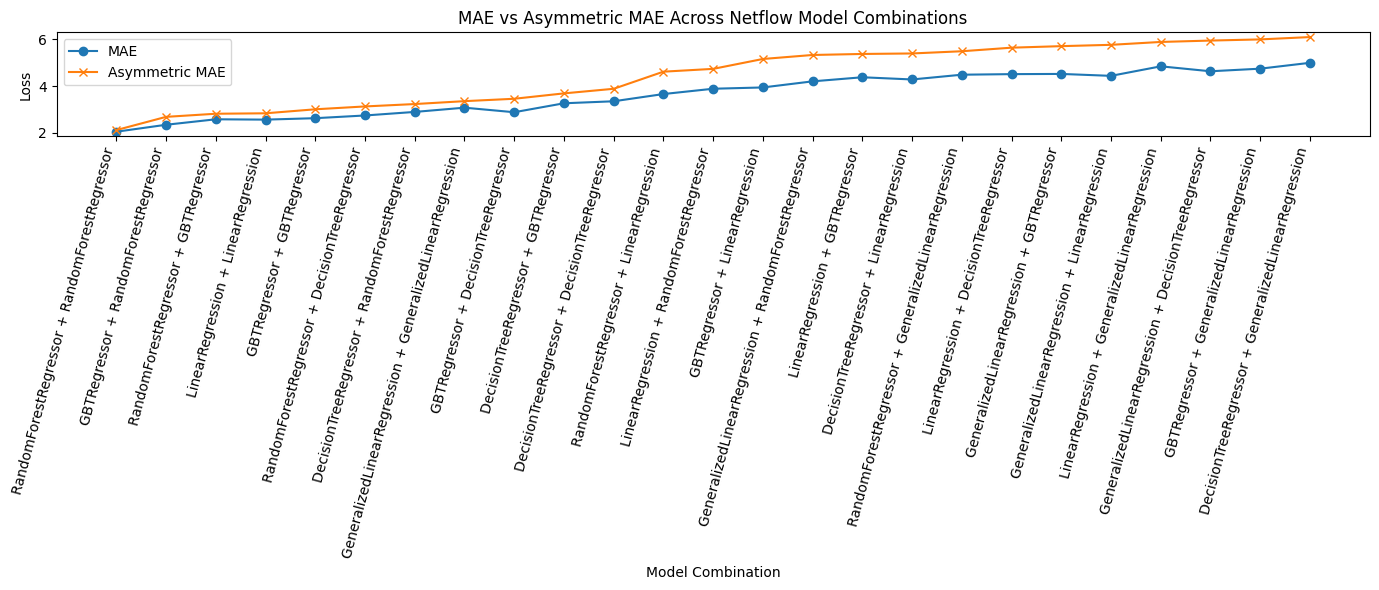

In [ ]:
plot_df = combo_metrics_pdf.sort_values("asymmetric_mae_mean", ascending=True).copy()
x = range(len(plot_df))

plt.figure(figsize=(14, 6))
plt.plot(x, plot_df["mae"], marker="o", label="MAE")
plt.plot(x, plot_df["asymmetric_mae_mean"], marker="x", label="Asymmetric MAE")
plt.xticks(x, plot_df["inflow_model"] + " + " + plot_df["outflow_model"], rotation=75, ha="right")
plt.ylabel("Loss")
plt.xlabel("Model Combination")
plt.title("MAE vs Asymmetric MAE Across Netflow Model Combinations")
plt.legend()
plt.tight_layout()
plt.show()

#### Visualise loss over time for the best combination

Other than the average loss per combination above,

Below, plotting time-wise loss. Rebuild best combo's joined prediction dataframe and calculate row-level loss.

In [ ]:
best_inflow_name = best_netflow_combo["inflow_model"]
best_outflow_name = best_netflow_combo["outflow_model"]

# fetch matching prediction DataFrames for the best combo
best_inflow_result = next(x for x in final_results if x["model_name"] == best_inflow_name)
best_outflow_result = next(x for x in final_results_outflow if x["model_name"] == best_outflow_name)
best_inflow_pred_df = best_inflow_result["predictions"]
best_outflow_pred_df = best_outflow_result["predictions"]

# rebuild network output n loss columns
best_inflow_sel = best_inflow_pred_df.select(
    "ts_hour",
    F.col(TARGET_COL).alias("actual_inflow"),
    F.col("prediction").alias("predicted_inflow")
)

best_outflow_sel = best_outflow_pred_df.select(
    "ts_hour",
    F.col(TARGET_COL).alias("actual_outflow"),
    F.col("prediction").alias("predicted_outflow")
)

best_netflow_output_df = (
    best_inflow_sel.join(best_outflow_sel, on=["ts_hour"], how="inner")
    .withColumn("actual_netflow", F.col("actual_inflow") - F.col("actual_outflow"))
    .withColumn("predicted_netflow", F.col("predicted_inflow") - F.col("predicted_outflow"))
    .withColumn("abs_error", F.abs(F.col("predicted_netflow") - F.col("actual_netflow")))
    .withColumn(
        "asym_abs_error",
        F.when(
            F.col("predicted_netflow") > F.col("actual_netflow"),
            F.abs(F.col("predicted_netflow") - F.col("actual_netflow")) * 2.0
        ).otherwise(
            F.abs(F.col("predicted_netflow") - F.col("actual_netflow"))
        )
    )
)

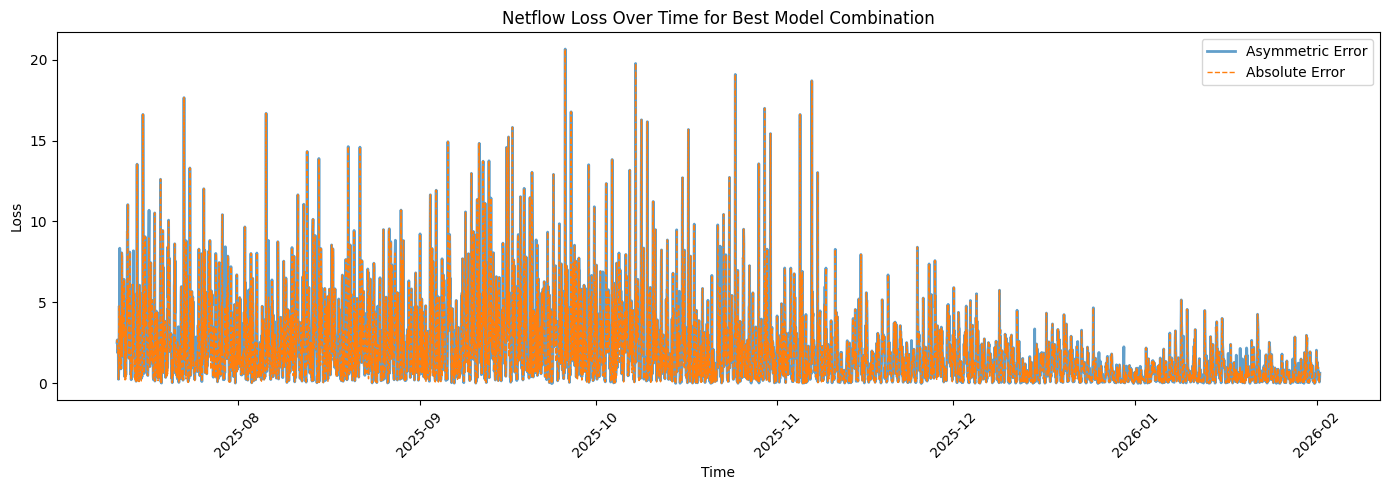

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    best_netflow_pdf["ts_hour"],
    best_netflow_pdf["asym_abs_error"],
    label="Asymmetric Error",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    best_netflow_pdf["ts_hour"],
    best_netflow_pdf["abs_error"],
    label="Absolute Error",
    linewidth=1,
    linestyle="--"
)

plt.xticks(rotation=45)
plt.ylabel("Loss")
plt.xlabel("Time")
plt.title("Netflow Loss Over Time for Best Model Combination")
plt.legend()
plt.tight_layout()
plt.show()

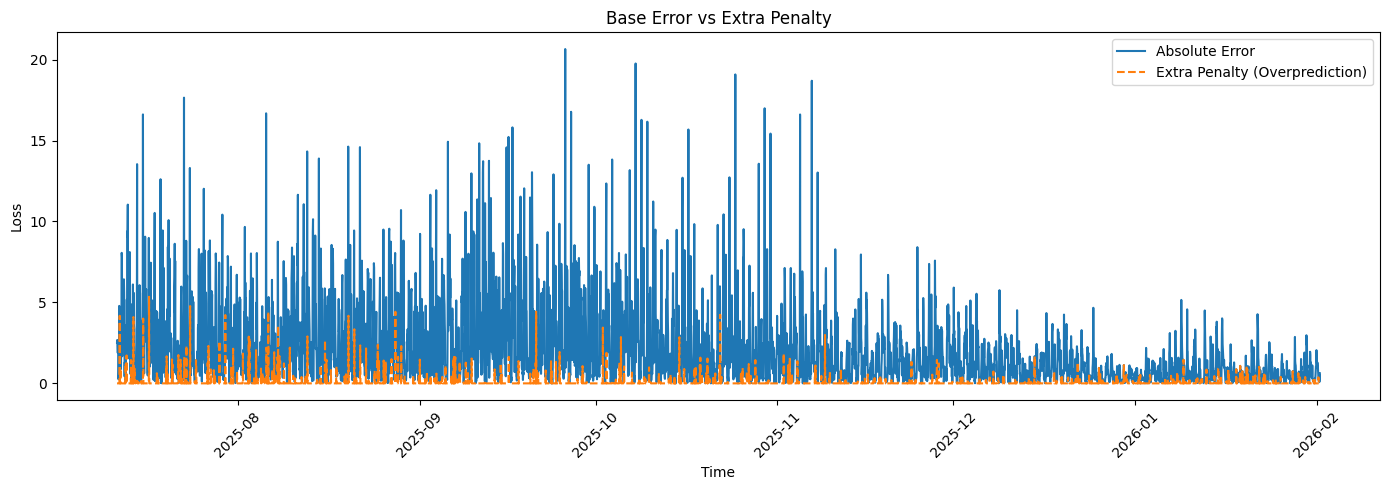

In [ ]:
best_netflow_pdf["extra_penalty"] = (
    best_netflow_pdf["asym_abs_error"] - best_netflow_pdf["abs_error"]
)

plt.figure(figsize=(14, 5))

plt.plot(
    best_netflow_pdf["ts_hour"],
    best_netflow_pdf["abs_error"],
    label="Absolute Error",
)

plt.plot(
    best_netflow_pdf["ts_hour"],
    best_netflow_pdf["extra_penalty"],
    label="Extra Penalty (Overprediction)",
    linestyle="--"
)

plt.xticks(rotation=45)
plt.ylabel("Loss")
plt.xlabel("Time")
plt.title("Base Error vs Extra Penalty")
plt.legend()
plt.tight_layout()
plt.show()

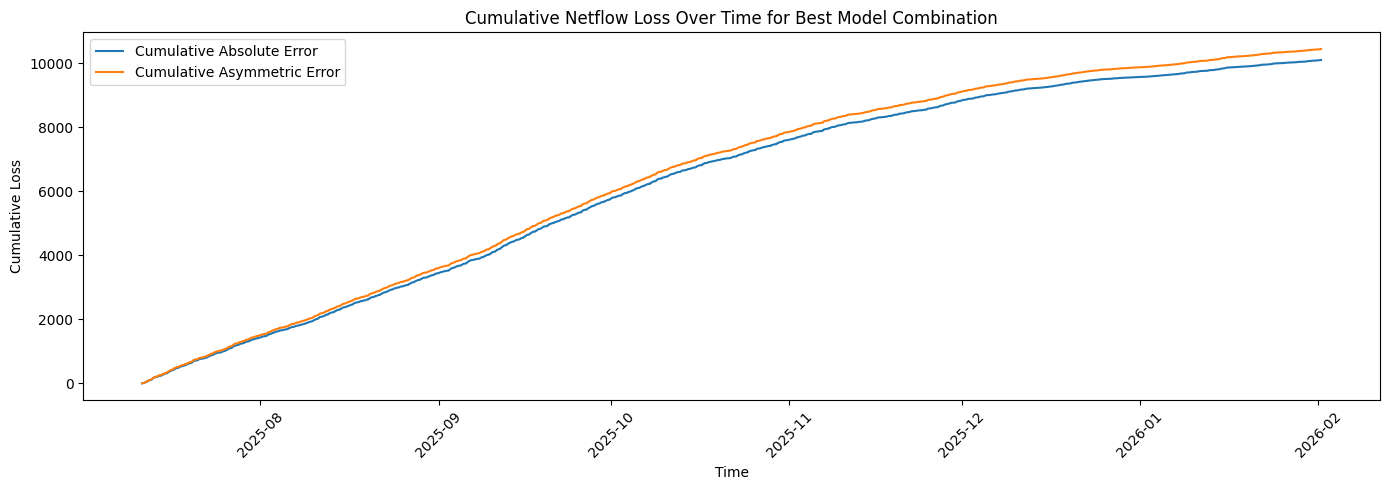

In [ ]:
best_netflow_pdf["cum_abs_error"] = best_netflow_pdf["abs_error"].cumsum()
best_netflow_pdf["cum_asym_abs_error"] = best_netflow_pdf["asym_abs_error"].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(best_netflow_pdf["ts_hour"], best_netflow_pdf["cum_abs_error"], label="Cumulative Absolute Error")
plt.plot(best_netflow_pdf["ts_hour"], best_netflow_pdf["cum_asym_abs_error"], label="Cumulative Asymmetric Error")
plt.xticks(rotation=45)
plt.ylabel("Cumulative Loss")
plt.xlabel("Time")
plt.title("Cumulative Netflow Loss Over Time for Best Model Combination")
plt.legend()
plt.tight_layout()
plt.show()